# Groove Embedding (TempoCNN + Beat-Synchronous Multiband Onsets)

This notebook builds a low-dimensional rhythm/groove embedding from a selected track using a configurable audio snippet.

Pipeline:
1. Estimate global BPM with Essentia `TempoCNN`
2. Build a beat grid from BPM + optional `MANUAL_FIRST_ONSET_SEC` anchor
3. Optionally phase-align the beat grid to onset envelopes (`full`, `low_mid`, or `adaptive`)
4. Compute multiband onset envelopes (`low`, `mid`, `high`)
5. Pool onsets beat-synchronously at `SUBDIVISIONS_PER_BEAT` subdivisions per beat using `POOLING_MODE`
6. Flatten the mean subdivision profile into a compact groove embedding



In [1]:
from pathlib import Path
import urllib.request

import librosa
import matplotlib.pyplot as plt
import numpy as np
import essentia.standard as es

TRACK_CANDIDATES = [
    Path("music/aries-mix/water.mp3"),
    Path("../music/aries-mix/water.mp3"),
]

SNIPPET_SECONDS = 5000.0
SAMPLE_RATE = 44100
HOP_LENGTH = 256
N_FFT = 2048

# TempoCNN setup (automatic BPM source when MANUAL_BPM is None).
TEMPOCNN_SAMPLE_RATE = 11025
TEMPOCNN_MODEL_URL = "https://essentia.upf.edu/models/tempo/tempocnn/deeptemp-k16-3.pb"
TEMPOCNN_AUTO_DOWNLOAD_MODEL = True
TEMPOCNN_MODEL_CANDIDATES = [
    Path("models/deeptemp-k16-3.pb"),
    Path("../models/deeptemp-k16-3.pb"),
]

# Optional global phase alignment: shift all beat ticks by one constant offset
# to better match onset-strength peaks (helps with systematic early/late beat placement).
AUTO_PHASE_ALIGN = True
PHASE_ALIGN_MAX_SHIFT_SEC = 0.18
PHASE_ALIGN_STEP_SEC = 0.002

# Which onset envelope to use for beat-grid phase alignment.
# Options: "full", "low_mid", "adaptive"
PHASE_ALIGN_ENVELOPE_MODE = "adaptive"
PHASE_ALIGN_LOW_MID_WEIGHTS = (0.3, 0.7)  # (low, mid)
PHASE_ALIGN_ADAPTIVE_MARGIN = 0.01

# Optionally repair missing leading beats near t=0 by prepending 1-2 beats
# when the first beat is approximately N beat-periods from zero.
AUTO_PREPEND_START_BEATS = True
MAX_MISSING_START_BEATS = 2
START_BEAT_SNAP_TOL_SEC = 0.12

# Optional manual overrides.
# - MANUAL_BPM: if set, skip TempoCNN and use this BPM
# - MANUAL_FIRST_ONSET_SEC: optional initial phase anchor for beat-grid construction
MANUAL_BPM = None
MANUAL_FIRST_ONSET_SEC = 0.00

# Increase this (e.g., 8 or 16) for smaller beat-synchronous time bins.
SUBDIVISIONS_PER_BEAT = 4
BEATS_PER_BAR = 4

# Subdivision pooling strategy for beat-synchronous binning.
# Options: "center", "mean", "max", "topk_mean"
POOLING_MODE = "mean"
POOLING_TOPK = 3

BANDS_HZ = {
    "low": (40.0, 180.0),
    "mid": (180.0, 2000.0),
    "high": (2000.0, 10000.0),
}





In [2]:
def first_existing_path(candidates: list[Path]) -> Path:
    for candidate in candidates:
        resolved = candidate.expanduser().resolve()
        if resolved.exists():
            return resolved
    tried = [str(c.expanduser().resolve()) for c in candidates]
    raise FileNotFoundError(f"Could not find any candidate path. Tried: {tried}")


def resolve_tempocnn_model_file(
    candidates: list[Path],
    *,
    auto_download: bool,
    model_url: str,
) -> Path:
    for candidate in candidates:
        resolved = candidate.expanduser().resolve()
        if resolved.exists():
            return resolved

    target = candidates[0].expanduser().resolve()
    if auto_download:
        target.parent.mkdir(parents=True, exist_ok=True)
        print(f"Downloading TempoCNN model to: {target}")
        urllib.request.urlretrieve(model_url, target)
        return target

    tried = [str(c.expanduser().resolve()) for c in candidates]
    details = "\n".join(f"  - {item}" for item in tried)
    raise FileNotFoundError(
        f"TempoCNN model not found. Tried:\n{details}\nDownload from: {model_url}"
    )


def extract_tempocnn_tempo(
    audio_path: Path,
    *,
    snippet_seconds: float,
    sample_rate: int,
    model_file: Path,
) -> dict:
    audio_tc = es.MonoLoader(
        filename=str(audio_path),
        sampleRate=int(sample_rate),
        resampleQuality=4,
    )()
    audio_tc = audio_tc[: int(float(snippet_seconds) * int(sample_rate))]

    global_bpm, local_bpm_raw, local_probs_raw = es.TempoCNN(graphFilename=str(model_file))(audio_tc)
    local_bpm = np.asarray(local_bpm_raw, dtype=np.float32)
    local_probs = np.asarray(local_probs_raw, dtype=np.float32)

    # TempoCNN tutorial default windows: 12s with 6s hop.
    if local_bpm.size:
        patch_hop = 6.0
        patch_center = 6.0
        local_times = patch_center + np.arange(local_bpm.size, dtype=np.float32) * patch_hop
        local_times = np.clip(local_times, 0.0, float(audio_tc.size) / float(sample_rate)).astype(np.float32)
    else:
        local_times = np.array([], dtype=np.float32)

    return {
        "global_bpm": float(global_bpm),
        "local_bpm": local_bpm,
        "local_probs": local_probs,
        "local_times": local_times,
        "audio_tc": np.asarray(audio_tc, dtype=np.float32),
    }


def bpm_from_beat_times(beat_times: np.ndarray, fallback_bpm: float) -> float:
    beat_times = np.asarray(beat_times, dtype=np.float32)
    if beat_times.size >= 2:
        ibi = np.diff(beat_times.astype(np.float64))
        ibi = ibi[np.isfinite(ibi) & (ibi > 1e-6)]
        if ibi.size:
            return float(60.0 / np.median(ibi))

    if np.isfinite(fallback_bpm) and fallback_bpm > 0:
        return float(fallback_bpm)
    return float("nan")


def build_beat_grid_from_bpm_onset(
    audio_duration: float,
    bpm: float,
    first_onset_sec: float,
) -> np.ndarray:
    if bpm <= 0:
        raise ValueError("bpm must be positive.")

    beat_period = 60.0 / float(bpm)
    first_beat = float(np.clip(first_onset_sec, 0.0, float(audio_duration)))
    while first_beat - beat_period >= 0.0:
        first_beat -= beat_period

    beat_times = np.arange(first_beat, float(audio_duration) + beat_period, beat_period, dtype=np.float32)
    beat_times = beat_times[beat_times <= float(audio_duration)]

    if beat_times.size < 2:
        beat_times = np.arange(0.0, float(audio_duration) + beat_period, beat_period, dtype=np.float32)
        beat_times = beat_times[beat_times <= float(audio_duration)]

    return beat_times


def normalize_to_unit_peak(x: np.ndarray) -> np.ndarray:
    arr = np.asarray(x, dtype=np.float32).reshape(-1)
    if arr.size == 0:
        return arr
    peak = float(np.max(np.abs(arr)))
    if peak <= 0.0:
        return np.zeros_like(arr, dtype=np.float32)
    return (arr / peak).astype(np.float32)


def estimate_global_onset_phase_shift_score(
    beat_times: np.ndarray,
    onset_times: np.ndarray,
    onset_env: np.ndarray,
    max_shift_sec: float = 0.18,
    step_sec: float = 0.002,
) -> tuple[float, float]:
    beat_times = np.asarray(beat_times, dtype=np.float32)
    onset_times = np.asarray(onset_times, dtype=np.float32)
    onset_env = normalize_to_unit_peak(np.asarray(onset_env, dtype=np.float32))

    if beat_times.size == 0 or onset_times.size == 0 or onset_env.size == 0:
        return 0.0, float("-inf")

    max_shift_sec = float(max(0.0, max_shift_sec))
    step_sec = float(max(1e-4, step_sec))

    shifts = np.arange(-max_shift_sec, max_shift_sec + step_sec, step_sec, dtype=np.float32)
    tmin = float(onset_times[0])
    tmax = float(onset_times[-1])

    best_shift = 0.0
    best_score = float("-inf")

    for shift in shifts:
        query = beat_times + float(shift)
        valid = (query >= tmin) & (query <= tmax)
        if not np.any(valid):
            continue

        score = float(np.mean(np.interp(query[valid], onset_times, onset_env)))
        if score > best_score:
            best_score = score
            best_shift = float(shift)

    return best_shift, best_score


def prepend_missing_start_beats(
    beat_times: np.ndarray,
    duration_sec: float,
    fallback_bpm: float,
    max_missing_beats: int = 2,
    snap_tolerance_sec: float = 0.12,
) -> tuple[np.ndarray, int]:
    beats = np.asarray(beat_times, dtype=np.float32)
    beats = beats[np.isfinite(beats)]
    beats = np.unique(beats)
    beats = beats[(beats >= 0.0) & (beats <= float(duration_sec))]

    if beats.size == 0:
        return beats, 0

    if beats.size >= 2:
        ibi = np.diff(beats.astype(np.float64))
        ibi = ibi[np.isfinite(ibi) & (ibi > 1e-6)]
        beat_period = float(np.median(ibi)) if ibi.size else float('nan')
    elif np.isfinite(fallback_bpm) and fallback_bpm > 0:
        beat_period = float(60.0 / fallback_bpm)
    else:
        beat_period = float('nan')

    if not np.isfinite(beat_period) or beat_period <= 0:
        return beats, 0

    max_missing_beats = int(max(0, max_missing_beats))
    snap_tolerance_sec = float(max(0.0, snap_tolerance_sec))
    first = float(beats[0])

    for n in range(1, max_missing_beats + 1):
        candidate = first - n * beat_period
        if abs(candidate) <= snap_tolerance_sec:
            prep = first - beat_period * np.arange(n, 0, -1, dtype=np.float32)
            prep = np.clip(prep, 0.0, float(duration_sec)).astype(np.float32)
            merged = np.unique(np.concatenate([prep, beats]).astype(np.float32))
            return merged, int(n)

    return beats, 0


def band_onset_flux(
    stft_magnitude: np.ndarray,
    frequencies_hz: np.ndarray,
    band_low_hz: float,
    band_high_hz: float,
) -> np.ndarray:
    mask = (frequencies_hz >= band_low_hz) & (frequencies_hz < band_high_hz)
    if not np.any(mask):
        return np.zeros(stft_magnitude.shape[1], dtype=np.float32)

    band_mag = stft_magnitude[mask]
    positive_flux = np.maximum(np.diff(band_mag, axis=1), 0.0)
    env = positive_flux.mean(axis=0).astype(np.float32)
    env = np.pad(env, (1, 0), mode="constant")
    env /= float(np.max(env)) + 1e-8
    return env


def beat_sync_multiband_tensor(
    beat_times: np.ndarray,
    frame_times: np.ndarray,
    band_envs: list[np.ndarray],
    subdivisions: int | None = None,
    pooling_mode: str | None = None,
    pooling_topk: int | None = None,
) -> np.ndarray:
    if subdivisions is None:
        subdivisions = int(SUBDIVISIONS_PER_BEAT)
    subdivisions = int(subdivisions)
    if subdivisions <= 0:
        raise ValueError("subdivisions must be a positive integer.")

    if pooling_mode is None:
        pooling_mode = str(POOLING_MODE)
    pooling_mode = str(pooling_mode).strip().lower()
    if pooling_mode not in {"center", "mean", "max", "topk_mean"}:
        raise ValueError("pooling_mode must be one of {'center', 'mean', 'max', 'topk_mean'}.")

    if pooling_topk is None:
        pooling_topk = int(POOLING_TOPK)
    pooling_topk = int(max(1, pooling_topk))

    n_intervals = max(0, int(beat_times.size) - 1)
    tensor = np.zeros((n_intervals, subdivisions, len(band_envs)), dtype=np.float32)

    for i in range(n_intervals):
        start = float(beat_times[i])
        end = float(beat_times[i + 1])
        if end <= start:
            continue

        subdivision_edges = start + (np.arange(subdivisions + 1, dtype=np.float32) / subdivisions) * (end - start)
        subdivision_centers = start + ((np.arange(subdivisions) + 0.5) / subdivisions) * (end - start)
        for b, env in enumerate(band_envs):
            env = np.asarray(env, dtype=np.float32)
            if pooling_mode == "center":
                tensor[i, :, b] = np.interp(subdivision_centers, frame_times, env).astype(np.float32)
                continue

            pooled = np.zeros(subdivisions, dtype=np.float32)
            for s in range(subdivisions):
                left = float(subdivision_edges[s])
                right = float(subdivision_edges[s + 1])
                if s == subdivisions - 1:
                    mask = (frame_times >= left) & (frame_times <= right)
                else:
                    mask = (frame_times >= left) & (frame_times < right)

                values = env[mask]
                if values.size == 0:
                    pooled[s] = float(np.interp(subdivision_centers[s], frame_times, env))
                    continue

                if pooling_mode == "mean":
                    pooled[s] = float(np.mean(values))
                elif pooling_mode == "max":
                    pooled[s] = float(np.max(values))
                else:
                    k = int(min(pooling_topk, values.size))
                    pooled[s] = float(np.mean(np.sort(values)[-k:]))

            tensor[i, :, b] = pooled

    # Per-beat normalization removes level differences and keeps rhythmic profile.
    tensor /= np.sum(tensor, axis=(1, 2), keepdims=True) + 1e-8
    return tensor



In [3]:
track_path = first_existing_path(TRACK_CANDIDATES)

audio = es.MonoLoader(
    filename=str(track_path),
    sampleRate=SAMPLE_RATE,
    resampleQuality=4,
)()
audio = audio[: int(SNIPPET_SECONDS * SAMPLE_RATE)]
duration_sec = len(audio) / SAMPLE_RATE

onset_env = librosa.onset.onset_strength(y=audio, sr=SAMPLE_RATE, hop_length=HOP_LENGTH)
onset_env_times = librosa.times_like(onset_env, sr=SAMPLE_RATE, hop_length=HOP_LENGTH)

phase_shift_sec = 0.0
prepended_count = 0
phase_align_scores: dict[str, float] = {}
phase_align_shifts: dict[str, float] = {}
phase_align_mode_used = "none"

audio_tc = np.array([], dtype=np.float32)
local_bpm = np.array([], dtype=np.float32)
local_probs = np.array([], dtype=np.float32)
local_times = np.array([], dtype=np.float32)

tempocnn_model_file: Path | None = None
tempocnn_bpm = float('nan')

if MANUAL_BPM is None:
    tempocnn_model_file = resolve_tempocnn_model_file(
        TEMPOCNN_MODEL_CANDIDATES,
        auto_download=bool(TEMPOCNN_AUTO_DOWNLOAD_MODEL),
        model_url=TEMPOCNN_MODEL_URL,
    )
    tempo_result = extract_tempocnn_tempo(
        track_path,
        snippet_seconds=SNIPPET_SECONDS,
        sample_rate=TEMPOCNN_SAMPLE_RATE,
        model_file=tempocnn_model_file,
    )
    tempocnn_bpm = float(tempo_result['global_bpm'])
    audio_tc = np.asarray(tempo_result['audio_tc'], dtype=np.float32)
    local_bpm = np.asarray(tempo_result['local_bpm'], dtype=np.float32)
    local_probs = np.asarray(tempo_result['local_probs'], dtype=np.float32)
    local_times = np.asarray(tempo_result['local_times'], dtype=np.float32)

    bpm_seed = float(tempocnn_bpm) if np.isfinite(tempocnn_bpm) and tempocnn_bpm > 0 else 120.0
    beat_phase_sec = 0.0 if MANUAL_FIRST_ONSET_SEC is None else float(MANUAL_FIRST_ONSET_SEC)
    beat_times = build_beat_grid_from_bpm_onset(
        audio_duration=duration_sec,
        bpm=bpm_seed,
        first_onset_sec=beat_phase_sec,
    )
    beat_source = "tempocnn_grid"
else:
    bpm_seed = float(MANUAL_BPM)
    beat_phase_sec = 0.0 if MANUAL_FIRST_ONSET_SEC is None else float(MANUAL_FIRST_ONSET_SEC)
    beat_times = build_beat_grid_from_bpm_onset(
        audio_duration=duration_sec,
        bpm=bpm_seed,
        first_onset_sec=beat_phase_sec,
    )
    beat_source = "manual_bpm_grid"

if AUTO_PHASE_ALIGN and beat_times.size >= 2:
    alignment_candidates: dict[str, tuple[np.ndarray, np.ndarray]] = {}

    # Full-band onset envelope candidate (current/default behavior).
    alignment_candidates["full"] = (
        np.asarray(onset_env_times, dtype=np.float32),
        normalize_to_unit_peak(np.asarray(onset_env, dtype=np.float32)),
    )

    # Low-mid multiband candidate for beat alignment robustness.
    stft_mag_phase = np.abs(
        librosa.stft(audio.astype(np.float32), n_fft=N_FFT, hop_length=HOP_LENGTH, center=True)
    )
    freqs_hz_phase = librosa.fft_frequencies(sr=SAMPLE_RATE, n_fft=N_FFT)
    frame_times_phase = librosa.frames_to_time(
        np.arange(stft_mag_phase.shape[1]),
        sr=SAMPLE_RATE,
        hop_length=HOP_LENGTH,
    ).astype(np.float32)

    low_band = BANDS_HZ.get("low")
    mid_band = BANDS_HZ.get("mid")
    if low_band is not None and mid_band is not None:
        low_env_phase = band_onset_flux(stft_mag_phase, freqs_hz_phase, *low_band)
        mid_env_phase = band_onset_flux(stft_mag_phase, freqs_hz_phase, *mid_band)
        low_w, mid_w = PHASE_ALIGN_LOW_MID_WEIGHTS
        low_mid_env_phase = normalize_to_unit_peak(
            (float(low_w) * low_env_phase + float(mid_w) * mid_env_phase).astype(np.float32)
        )
        if low_mid_env_phase.size == frame_times_phase.size and np.any(low_mid_env_phase > 0):
            alignment_candidates["low_mid"] = (frame_times_phase, low_mid_env_phase)

    for mode_name, (cand_times, cand_env) in alignment_candidates.items():
        shift, score = estimate_global_onset_phase_shift_score(
            beat_times=beat_times,
            onset_times=cand_times,
            onset_env=cand_env,
            max_shift_sec=PHASE_ALIGN_MAX_SHIFT_SEC,
            step_sec=PHASE_ALIGN_STEP_SEC,
        )
        phase_align_shifts[mode_name] = float(shift)
        phase_align_scores[mode_name] = float(score)

    requested_mode = str(PHASE_ALIGN_ENVELOPE_MODE).strip().lower()
    if requested_mode not in {"full", "low_mid", "adaptive"}:
        raise ValueError(
            "PHASE_ALIGN_ENVELOPE_MODE must be one of {'full', 'low_mid', 'adaptive'}."
        )

    if requested_mode == "full":
        phase_align_mode_used = "full"
    elif requested_mode == "low_mid":
        phase_align_mode_used = "low_mid" if "low_mid" in phase_align_shifts else "full"
    else:
        # Adaptive: use low-mid only when it clearly scores better.
        if "full" in phase_align_scores and "low_mid" in phase_align_scores:
            full_score = phase_align_scores["full"]
            low_mid_score = phase_align_scores["low_mid"]
            if low_mid_score >= full_score + float(PHASE_ALIGN_ADAPTIVE_MARGIN):
                phase_align_mode_used = "low_mid"
            else:
                phase_align_mode_used = "full"
        elif "low_mid" in phase_align_scores:
            phase_align_mode_used = "low_mid"
        else:
            phase_align_mode_used = "full"

    phase_shift_sec = float(phase_align_shifts.get(phase_align_mode_used, 0.0))

    shifted = beat_times + float(phase_shift_sec)
    shifted = shifted[(shifted >= 0.0) & (shifted <= duration_sec)]
    shifted = np.unique(shifted.astype(np.float32))
    if shifted.size >= 2:
        beat_times = shifted
        beat_source = f"{beat_source}_phase_aligned_{phase_align_mode_used}"

if AUTO_PREPEND_START_BEATS:
    beat_times, prepended_count = prepend_missing_start_beats(
        beat_times=beat_times,
        duration_sec=duration_sec,
        fallback_bpm=bpm_seed,
        max_missing_beats=MAX_MISSING_START_BEATS,
        snap_tolerance_sec=START_BEAT_SNAP_TOL_SEC,
    )
    if prepended_count > 0:
        beat_source = f"{beat_source}_prepended_start_{prepended_count}"

global_bpm = bpm_from_beat_times(beat_times, fallback_bpm=bpm_seed)

print(f"Track: {track_path}")
print(f"Analyzed duration: {duration_sec:.2f} s")
print(f"Beat source: {beat_source}")
if MANUAL_BPM is None:
    print(f"TempoCNN BPM: {tempocnn_bpm:.2f}")
    if tempocnn_model_file is not None:
        print(f"TempoCNN model: {tempocnn_model_file}")
    print(f"TempoCNN local patches: {len(local_bpm)}")
else:
    print(f"Manual BPM: {bpm_seed:.2f}")
print(f"BPM from beat ticks (median IBI): {global_bpm:.2f}")
print(f"Prepended start beats: {prepended_count}")
if AUTO_PHASE_ALIGN:
    print(
        f"Phase alignment envelope: requested={PHASE_ALIGN_ENVELOPE_MODE}, used={phase_align_mode_used}"
    )
    if phase_align_scores:
        score_str = ", ".join(
            f"{k}={phase_align_scores[k]:.4f} (shift={phase_align_shifts[k]:+0.4f}s)"
            for k in sorted(phase_align_scores.keys())
        )
        print(f"Phase alignment scores: {score_str}")
    print(f"Applied global phase shift: {phase_shift_sec:+.4f} s")
print(f"Beat onsets in snippet: {len(beat_times)}")
print(f"First onset/phase anchor: {beat_phase_sec:.4f} s")



[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/deeptemp-k16-3.pb`
I0000 00:00:1780959698.313215 23995279 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


Track: /Users/josephdaher/Git Repositories/djprojectexploration/music/aries-mix/water.mp3
Analyzed duration: 256.92 s
Beat source: tempocnn_grid_phase_aligned_low_mid_prepended_start_1
TempoCNN BPM: 130.00
TempoCNN model: /Users/josephdaher/Git Repositories/djprojectexploration/models/deeptemp-k16-3.pb
TempoCNN local patches: 42
BPM from beat ticks (median IBI): 130.00
Prepended start beats: 1
Phase alignment envelope: requested=adaptive, used=low_mid
Phase alignment scores: full=0.3286 (shift=-0.0400s), low_mid=0.5170 (shift=-0.0580s)
Applied global phase shift: -0.0580 s
Beat onsets in snippet: 557
First onset/phase anchor: 0.0000 s


In [4]:
stft_mag = np.abs(librosa.stft(audio.astype(np.float32), n_fft=N_FFT, hop_length=HOP_LENGTH, center=True))
freqs_hz = librosa.fft_frequencies(sr=SAMPLE_RATE, n_fft=N_FFT)
frame_times = librosa.frames_to_time(np.arange(stft_mag.shape[1]), sr=SAMPLE_RATE, hop_length=HOP_LENGTH)

band_names = list(BANDS_HZ.keys())
band_envs = [
    band_onset_flux(stft_mag, freqs_hz, *BANDS_HZ[name])
    for name in band_names
]

beat_sync_tensor = beat_sync_multiband_tensor(
    beat_times=beat_times,
    frame_times=frame_times,
    band_envs=band_envs,
    subdivisions=SUBDIVISIONS_PER_BEAT,
    pooling_mode=POOLING_MODE,
    pooling_topk=POOLING_TOPK,
)

n_bar_subdivisions = SUBDIVISIONS_PER_BEAT * BEATS_PER_BAR

if beat_sync_tensor.size == 0:
    groove_profile = np.zeros((SUBDIVISIONS_PER_BEAT, len(band_names)), dtype=np.float32)
    groove_profile_bar = np.zeros((n_bar_subdivisions, len(band_names)), dtype=np.float32)
    n_complete_bars = 0
else:
    groove_profile = beat_sync_tensor.mean(axis=0).astype(np.float32)

    n_complete_beats = (beat_sync_tensor.shape[0] // BEATS_PER_BAR) * BEATS_PER_BAR
    if n_complete_beats >= BEATS_PER_BAR:
        bar_tensor = beat_sync_tensor[:n_complete_beats].reshape(
            -1,
            BEATS_PER_BAR,
            SUBDIVISIONS_PER_BEAT,
            len(band_names),
        )
        bar_tensor = bar_tensor.reshape(bar_tensor.shape[0], n_bar_subdivisions, len(band_names))
        groove_profile_bar = bar_tensor.mean(axis=0).astype(np.float32)
        n_complete_bars = int(bar_tensor.shape[0])
    else:
        groove_profile_bar = np.zeros((n_bar_subdivisions, len(band_names)), dtype=np.float32)
        n_complete_bars = 0

groove_embedding = groove_profile.reshape(-1)

print(f"Beat-synchronous tensor shape: {beat_sync_tensor.shape} (beats-1, subdivisions, bands)")
print(f"Subdivision pooling: mode={POOLING_MODE}, topk={POOLING_TOPK}")
print(f"Groove profile shape: {groove_profile.shape} (subdivisions, bands)")
print(f"Bar profile shape: {groove_profile_bar.shape} (bar subdivisions, bands)")
print(f"Complete bars used: {n_complete_bars}")
print(f"Groove embedding dimensionality: {groove_embedding.shape[0]}")
print("Embedding vector:")
print(np.array2string(groove_embedding, precision=5, separator=", "))

Beat-synchronous tensor shape: (556, 4, 3) (beats-1, subdivisions, bands)
Subdivision pooling: mode=mean, topk=3
Groove profile shape: (4, 3) (subdivisions, bands)
Bar profile shape: (16, 3) (bar subdivisions, bands)
Complete bars used: 139
Groove embedding dimensionality: 12
Embedding vector:
[0.09391, 0.08968, 0.13095, 0.02729, 0.0689 , 0.12411, 0.02925, 0.07183,
 0.13187, 0.0288 , 0.08687, 0.11654]


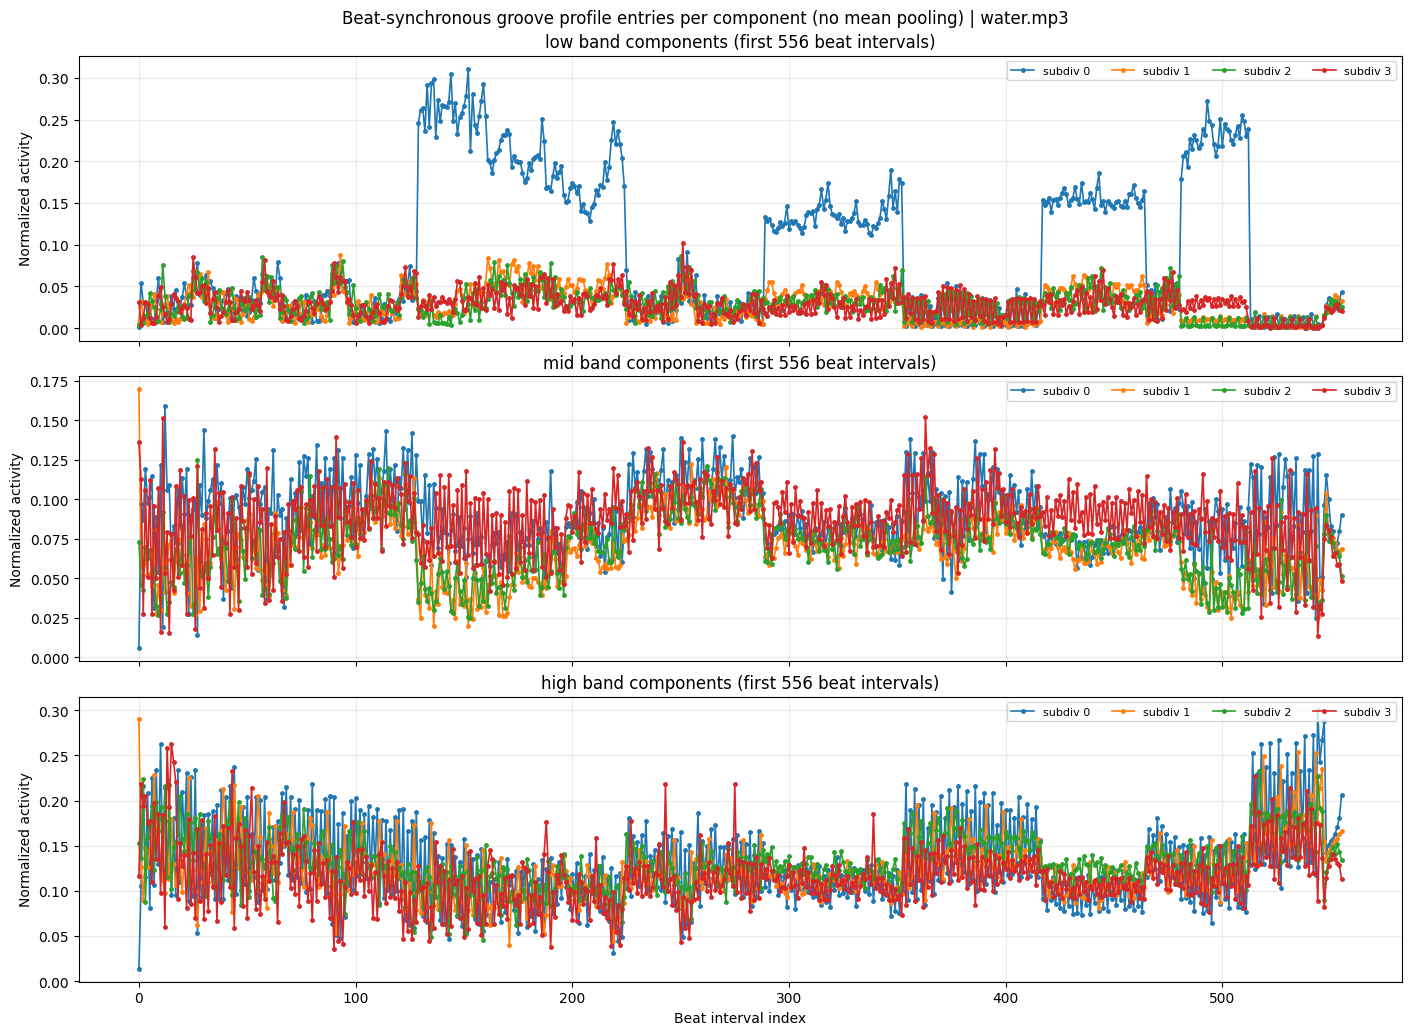

In [5]:
from pathlib import Path

MAX_ENTRIES = 1024
track_title = Path(str(track_path)).name if "track_path" in globals() else "<unknown>"
n_entries = min(MAX_ENTRIES, int(beat_sync_tensor.shape[0]))

if n_entries == 0:
    raise RuntimeError("No beat-synchronous entries to plot. Run the previous cells first.")

x = np.arange(n_entries, dtype=np.int32)
fig, axes = plt.subplots(len(band_names), 1, figsize=(14, 10), sharex=True, constrained_layout=True)
axes = np.atleast_1d(axes)

for b, ax in enumerate(axes):
    for s in range(SUBDIVISIONS_PER_BEAT):
        y = beat_sync_tensor[:n_entries, s, b]
        ax.plot(x, y, linewidth=1.2, marker="o", markersize=2.5, label=f"subdiv {s}")
    ax.set_title(f"{band_names[b]} band components (first {n_entries} beat intervals)")
    ax.set_ylabel("Normalized activity")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right", ncol=min(4, SUBDIVISIONS_PER_BEAT), fontsize=8)

axes[-1].set_xlabel("Beat interval index")
fig.suptitle(f"Beat-synchronous groove profile entries per component (no mean pooling) | {track_title}", y=1.02)
plt.show()


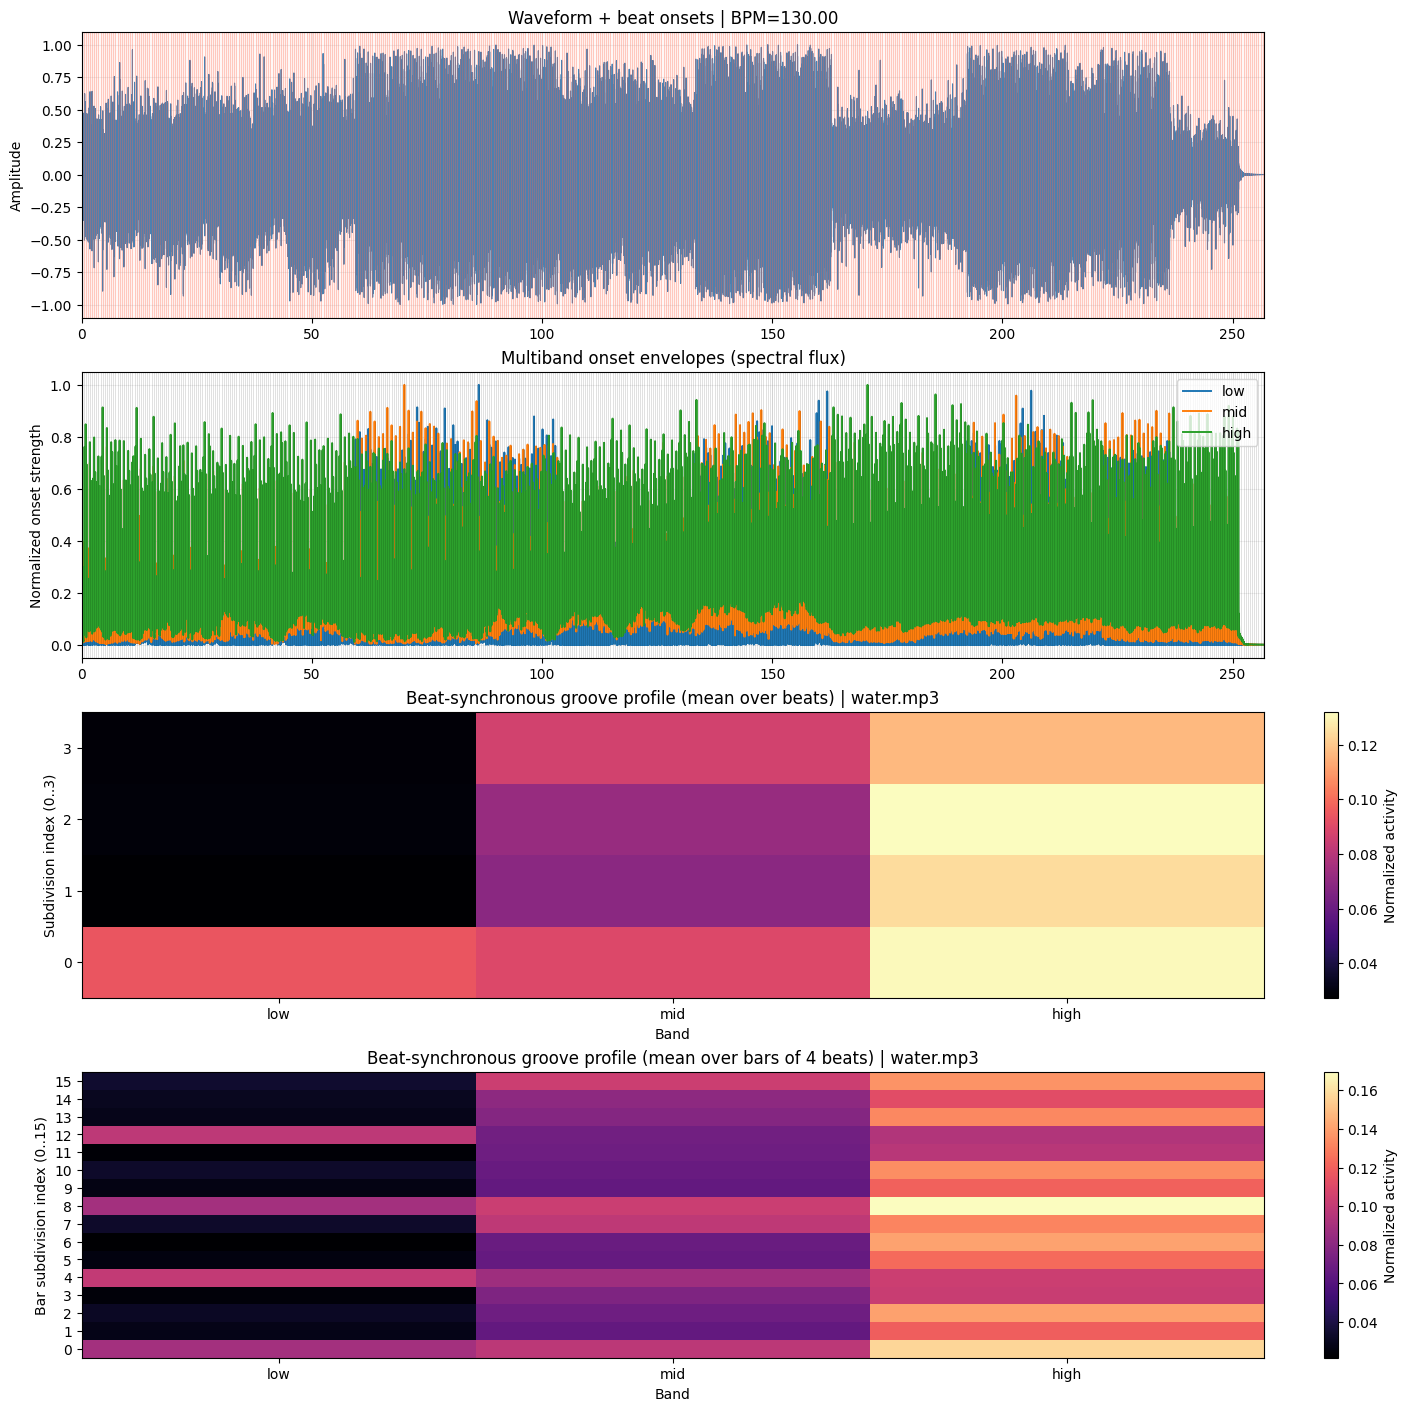

In [6]:
from pathlib import Path

time_sec = np.arange(len(audio), dtype=np.float32) / SAMPLE_RATE
track_title = Path(str(track_path)).name if "track_path" in globals() else "<unknown>"
plot_stride = max(1, len(audio) // 120000)

fig, axes = plt.subplots(4, 1, figsize=(14, 14), constrained_layout=True)

axes[0].plot(time_sec[::plot_stride], audio[::plot_stride], color="steelblue", linewidth=0.8)
for bt in beat_times:
    axes[0].axvline(float(bt), color="tomato", alpha=0.35, linewidth=0.9)
axes[0].set_xlim(0.0, duration_sec)
axes[0].set_title(f"Waveform + beat onsets | BPM={global_bpm:.2f}")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.2)

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
for env, name, color in zip(band_envs, band_names, colors):
    axes[1].plot(frame_times, env, linewidth=1.4, label=name, color=color)
for bt in beat_times:
    axes[1].axvline(float(bt), color="black", alpha=0.12, linewidth=0.7)
axes[1].set_xlim(0.0, duration_sec)
axes[1].set_title("Multiband onset envelopes (spectral flux)")
axes[1].set_ylabel("Normalized onset strength")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.2)

im = axes[2].imshow(groove_profile, aspect="auto", origin="lower", cmap="magma")
axes[2].set_title(f"Beat-synchronous groove profile (mean over beats) | {track_title}")
axes[2].set_xlabel("Band")
axes[2].set_ylabel(f"Subdivision index (0..{SUBDIVISIONS_PER_BEAT - 1})")
axes[2].set_xticks(range(len(band_names)), labels=band_names)
axes[2].set_yticks(range(SUBDIVISIONS_PER_BEAT))
fig.colorbar(im, ax=axes[2], label="Normalized activity")

im_bar = axes[3].imshow(groove_profile_bar, aspect="auto", origin="lower", cmap="magma")
axes[3].set_title(f"Beat-synchronous groove profile (mean over bars of {BEATS_PER_BAR} beats) | {track_title}")
axes[3].set_xlabel("Band")
axes[3].set_ylabel(f"Bar subdivision index (0..{n_bar_subdivisions - 1})")
axes[3].set_xticks(range(len(band_names)), labels=band_names)
axes[3].set_yticks(range(n_bar_subdivisions))
fig.colorbar(im_bar, ax=axes[3], label="Normalized activity")

plt.show()


In [7]:
# Interactive beatgrid alignment inspector (Plotly; scroll/zoom like rhythm embedding).
# Displays waveform + beat/subdivision grid and onset envelopes (regular + multiband).
import numpy as np
import librosa
import plotly.graph_objects as go
from plotly.subplots import make_subplots

if len(audio) == 0:
    raise RuntimeError("Audio buffer is empty.")

MAX_WAVE_POINTS = 120_000
SHOW_BEATGRID_GRID_LABELS = True
BEATGRID_LABEL_STEP = 1
BEATGRID_LABEL_FONT_SIZE = 9
BEATGRID_LABEL_MAX_POINTS = 800
BEATGRID_LABEL_ONLY_INITIAL_WINDOW = True
SHOW_BEATGRID_LABELS_ON_BOTTOM = False

def build_waveform_envelope(t: np.ndarray, y: np.ndarray, max_points: int = MAX_WAVE_POINTS):
    """Return min/max envelope polyline (with NaN separators) for fast waveform rendering."""
    n = y.size
    if n <= max_points:
        return t.astype(np.float32), y.astype(np.float32)

    bins = max(1, max_points // 2)
    bin_size = int(np.ceil(n / bins))
    padded = int(np.ceil(n / bin_size) * bin_size)

    if padded > n:
        pad_n = padded - n
        y_pad = np.pad(y, (0, pad_n), mode='edge')
        t_pad = np.pad(t, (0, pad_n), mode='edge')
    else:
        y_pad = y
        t_pad = t

    y2 = y_pad.reshape(-1, bin_size)
    t2 = t_pad.reshape(-1, bin_size)

    t_start = t2[:, 0]
    t_end = t2[:, -1]
    y_min = y2.min(axis=1)
    y_max = y2.max(axis=1)

    x_env = np.empty(t_start.size * 3, dtype=np.float32)
    y_env = np.empty(y_min.size * 3, dtype=np.float32)

    x_env[0::3] = t_start
    x_env[1::3] = t_end
    x_env[2::3] = np.nan

    y_env[0::3] = y_min
    y_env[1::3] = y_max
    y_env[2::3] = np.nan

    return x_env, y_env


def build_vertical_line_trace(
    events_sec: np.ndarray,
    ymin: float,
    ymax: float,
    color: str,
    name: str,
    *,
    dash: str = 'solid',
    width: float = 1.0,
    opacity: float = 0.45,
):
    """Pack vertical markers into one WebGL line trace for speed."""
    events = np.asarray(events_sec, dtype=np.float32).reshape(-1)
    if events.size == 0:
        return None

    x = np.empty(events.size * 3, dtype=np.float32)
    y = np.empty(events.size * 3, dtype=np.float32)

    x[0::3] = events
    x[1::3] = events
    x[2::3] = np.nan

    y[0::3] = ymin
    y[1::3] = ymax
    y[2::3] = np.nan

    return go.Scattergl(
        x=x,
        y=y,
        mode='lines',
        name=name,
        line=dict(color=color, width=width, dash=dash),
        opacity=opacity,
        hoverinfo='skip',
        showlegend=False,
    )


def build_grid_label_trace(
    events_sec: np.ndarray,
    labels: list[str] | np.ndarray,
    y_value: float,
    *,
    name: str = 'beat/subdiv labels',
    color: str = '#2f2f2f',
    font_size: int = BEATGRID_LABEL_FONT_SIZE,
    opacity: float = 0.85,
    label_step: int = BEATGRID_LABEL_STEP,
    max_labels: int = BEATGRID_LABEL_MAX_POINTS,
    xmin: float | None = None,
    xmax: float | None = None,
):
    """Return text labels for beat/subdivision markers (e.g., 1.1, 1.2, ...)."""
    events = np.asarray(events_sec, dtype=np.float32).reshape(-1)
    texts = np.asarray(labels, dtype=object).reshape(-1)
    if events.size == 0 or texts.size == 0:
        return None
    if events.size != texts.size:
        raise ValueError('events_sec and labels must have the same length.')

    keep_mask = np.isfinite(events)
    if xmin is not None:
        keep_mask &= (events >= float(xmin))
    if xmax is not None:
        keep_mask &= (events <= float(xmax))
    events = events[keep_mask]
    texts = texts[keep_mask]
    if events.size == 0:
        return None

    label_step = int(max(1, label_step))
    max_labels = int(max(0, max_labels))
    if max_labels > 0 and int(np.ceil(events.size / float(label_step))) > max_labels:
        auto_step = int(np.ceil(events.size / float(max_labels)))
        label_step = max(label_step, auto_step)

    if label_step > 1:
        idx = np.arange(0, events.size, label_step, dtype=np.int64)
        events = events[idx]
        texts = texts[idx]

    y = np.full(events.shape, float(y_value), dtype=np.float32)
    return go.Scatter(
        x=events,
        y=y,
        mode='text',
        text=texts.tolist(),
        textposition='middle center',
        textfont=dict(color=color, size=int(max(6, font_size))),
        name=name,
        hovertemplate='grid=%{text}<br>time=%{x:.3f}s<extra></extra>',
        showlegend=False,
        opacity=opacity,
    )


def normalize_env(x: np.ndarray) -> np.ndarray:
    arr = np.asarray(x, dtype=np.float32).reshape(-1)
    if arr.size == 0:
        return arr
    peak = float(np.max(np.abs(arr)))
    if peak <= 0.0:
        return np.zeros_like(arr, dtype=np.float32)
    return (arr / peak).astype(np.float32)


# Timeline/waveform data
if 'time_sec' not in globals():
    time_sec = np.arange(len(audio), dtype=np.float32) / SAMPLE_RATE
plot_t, plot_y = build_waveform_envelope(time_sec, audio.astype(np.float32))
wave_ymin = float(np.min(audio)) if len(audio) else -1.0
wave_ymax = float(np.max(audio)) if len(audio) else 1.0

# Beat and subdivision markers across the full snippet.
beats = np.asarray(beat_times, dtype=np.float32).reshape(-1)
subdivision_times: list[float] = []
if SUBDIVISIONS_PER_BEAT > 1 and beats.size >= 2:
    for i in range(beats.size - 1):
        b0 = float(beats[i])
        b1 = float(beats[i + 1])
        if b1 <= b0:
            continue
        for k in range(1, int(SUBDIVISIONS_PER_BEAT)):
            t = b0 + (k / float(SUBDIVISIONS_PER_BEAT)) * (b1 - b0)
            subdivision_times.append(float(t))
subdivision_times = np.asarray(subdivision_times, dtype=np.float32)

grid_label_times: list[float] = []
grid_label_text: list[str] = []
if beats.size >= 2 and int(SUBDIVISIONS_PER_BEAT) >= 1:
    for i in range(beats.size - 1):
        b0 = float(beats[i])
        b1 = float(beats[i + 1])
        if b1 <= b0:
            continue
        for k in range(int(SUBDIVISIONS_PER_BEAT)):
            t = b0 + (k / float(SUBDIVISIONS_PER_BEAT)) * (b1 - b0)
            grid_label_times.append(float(t))
            beat_number = i + 1
            bar_number = (i // max(1, int(BEATS_PER_BAR))) + 1
            subdivision_number = k + 1
            grid_label_text.append(f'{beat_number}.{bar_number}.{subdivision_number}')
grid_label_times = np.asarray(grid_label_times, dtype=np.float32)

# Onset envelopes: current regular onset strength + multiband envelopes.
onset_env_plot = normalize_env(np.asarray(onset_env, dtype=np.float32))
onset_times_plot = np.asarray(onset_env_times, dtype=np.float32)
if onset_times_plot.size != onset_env_plot.size:
    onset_times_plot = librosa.times_like(onset_env_plot, sr=SAMPLE_RATE, hop_length=HOP_LENGTH)

band_envs_plot = [normalize_env(np.asarray(env, dtype=np.float32)) for env in band_envs]
band_colors = {
    'low': '#1f77b4',
    'mid': '#ff7f0e',
    'high': '#2ca02c',
}

initial_window = min(30.0, float(duration_sec))
label_xmin = 0.0 if BEATGRID_LABEL_ONLY_INITIAL_WINDOW else None
label_xmax = initial_window if BEATGRID_LABEL_ONLY_INITIAL_WINDOW else None
grid_label_visible_mask = np.isfinite(grid_label_times)
if label_xmin is not None:
    grid_label_visible_mask &= (grid_label_times >= float(label_xmin))
if label_xmax is not None:
    grid_label_visible_mask &= (grid_label_times <= float(label_xmax))
grid_label_times_visible = grid_label_times[grid_label_visible_mask]
grid_label_text_visible = [
    str(txt)
    for txt, keep in zip(grid_label_text, grid_label_visible_mask.tolist(), strict=False)
    if bool(keep)
]

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=(
        f'Waveform + beatgrid ({beat_source}) | BPM={global_bpm:.2f}',
        'Onset envelopes: regular onset strength + multiband spectral flux',
    ),
)

# Row 1: waveform + beat/subdivision markers
fig.add_trace(
    go.Scattergl(
        x=plot_t,
        y=plot_y,
        mode='lines',
        name='waveform',
        line=dict(color='steelblue', width=1),
        hoverinfo='skip',
    ),
    row=1,
    col=1,
)

beat_lines_top = build_vertical_line_trace(
    beats,
    wave_ymin,
    wave_ymax,
    'tomato',
    'beat ticks',
    width=1.0,
    opacity=0.55,
)
if beat_lines_top is not None:
    fig.add_trace(beat_lines_top, row=1, col=1)

subdiv_lines_top = build_vertical_line_trace(
    subdivision_times,
    wave_ymin,
    wave_ymax,
    'deepskyblue',
    'subdivisions',
    dash='dot',
    width=1.0,
    opacity=0.30,
)
if subdiv_lines_top is not None:
    fig.add_trace(subdiv_lines_top, row=1, col=1)

if SHOW_BEATGRID_GRID_LABELS:
    wave_label_y = wave_ymax - 0.10 * max(1e-6, (wave_ymax - wave_ymin))
    label_trace_top = build_grid_label_trace(
        grid_label_times_visible,
        grid_label_text_visible,
        wave_label_y,
        color='#404040',
        font_size=BEATGRID_LABEL_FONT_SIZE,
        opacity=0.82,
        label_step=BEATGRID_LABEL_STEP,
        max_labels=BEATGRID_LABEL_MAX_POINTS,
    )
    if label_trace_top is not None:
        fig.add_trace(label_trace_top, row=1, col=1)

# Row 2: regular onset strength + multiband envelopes
fig.add_trace(
    go.Scattergl(
        x=onset_times_plot,
        y=onset_env_plot,
        mode='lines',
        name='onset strength (regular)',
        line=dict(color='#111111', width=2),
    ),
    row=2,
    col=1,
)

for name, env in zip(band_names, band_envs_plot, strict=False):
    if env.size == 0:
        continue
    color = band_colors.get(str(name), '#666666')
    fig.add_trace(
        go.Scattergl(
            x=frame_times,
            y=env,
            mode='lines',
            name=f'{name} band onset',
            line=dict(color=color, width=1.6),
        ),
        row=2,
        col=1,
    )

env_ymin = 0.0
env_ymax = 1.05

beat_lines_bottom = build_vertical_line_trace(
    beats,
    env_ymin,
    env_ymax,
    'tomato',
    'beat ticks',
    width=1.0,
    opacity=0.45,
)
if beat_lines_bottom is not None:
    fig.add_trace(beat_lines_bottom, row=2, col=1)

subdiv_lines_bottom = build_vertical_line_trace(
    subdivision_times,
    env_ymin,
    env_ymax,
    'deepskyblue',
    'subdivisions',
    dash='dot',
    width=1.0,
    opacity=0.24,
)
if subdiv_lines_bottom is not None:
    fig.add_trace(subdiv_lines_bottom, row=2, col=1)

if SHOW_BEATGRID_GRID_LABELS and SHOW_BEATGRID_LABELS_ON_BOTTOM:
    env_label_y = env_ymax - 0.10 * max(1e-6, (env_ymax - env_ymin))
    label_trace_bottom = build_grid_label_trace(
        grid_label_times_visible,
        grid_label_text_visible,
        env_label_y,
        color='#303030',
        font_size=max(7, BEATGRID_LABEL_FONT_SIZE - 1),
        opacity=0.68,
        label_step=BEATGRID_LABEL_STEP,
        max_labels=BEATGRID_LABEL_MAX_POINTS,
    )
    if label_trace_bottom is not None:
        fig.add_trace(label_trace_bottom, row=2, col=1)

fig.update_layout(
    title='Interactive Groove Beatgrid Inspector (horizontal zoom/pan)',
    height=820,
    template='plotly_white',
    hovermode='x unified',
    margin=dict(l=60, r=20, t=70, b=60),
    dragmode='pan',
    uirevision='groove-beatgrid-inspector',
)

fig.update_xaxes(range=[0.0, initial_window], row=1, col=1)
fig.update_xaxes(title_text='Time (seconds)', rangeslider_visible=True, row=2, col=1)
fig.update_yaxes(title_text='Amplitude', fixedrange=True, row=1, col=1)
fig.update_yaxes(title_text='Normalized onset strength', range=[env_ymin, env_ymax], row=2, col=1)

print(
    f'Beatgrid check: beats={beats.size} | subdivisions={subdivision_times.size} | '
    f'labels_total={grid_label_times.size} | label_step={BEATGRID_LABEL_STEP} | '
    f'labels_visible={grid_label_times_visible.size} | '
    f'label_max={BEATGRID_LABEL_MAX_POINTS} | '
    f'label_window={'initial' if BEATGRID_LABEL_ONLY_INITIAL_WINDOW else 'full'} | '
    f'window={initial_window:.2f}s of {duration_sec:.2f}s'
)
fig.show(config={'scrollZoom': True, 'displaylogo': False})



Beatgrid check: beats=557 | subdivisions=1668 | labels_total=2224 | label_step=1 | labels_visible=261 | label_max=800 | label_window=initial | window=30.00s of 256.92s


In [8]:
from pathlib import Path

import librosa
import numpy as np

# Energy / tonal-balance analysis for a specific song (global + windowed metrics).
# Typical macro window: 3.0s with 1.0s hop.

ENERGY_TRACK_CANDIDATES = [
    Path("../music/aries-mix/atnight.mp3"),
    Path("music/aries-mix/atnight.mp3"),
]
ENERGY_SAMPLE_RATE = 44100
ENERGY_WINDOW_SEC = 3.0
ENERGY_HOP_SEC = 1.0
ENERGY_N_FFT = 4096
ENERGY_STFT_HOP = 1024
ENERGY_DYN_FRAME_SEC = 0.05
ENERGY_DYN_HOP_SEC = 0.025

# Unweighted absolute band-power regions.
ENERGY_BANDS_HZ = {
    "low": (20.0, 250.0),
    "mid": (250.0, 2000.0),
    "high": (2000.0, 20000.0),
}

EPS = 1e-12

if "first_existing_path" in globals():
    energy_track_path = first_existing_path(ENERGY_TRACK_CANDIDATES)
else:
    for _candidate in ENERGY_TRACK_CANDIDATES:
        _resolved = _candidate.expanduser().resolve()
        if _resolved.exists():
            energy_track_path = _resolved
            break
    else:
        _tried = [str(c.expanduser().resolve()) for c in ENERGY_TRACK_CANDIDATES]
        raise FileNotFoundError(f"Could not find any candidate path. Tried: {_tried}")

energy_audio, energy_sr = librosa.load(
    str(energy_track_path),
    sr=ENERGY_SAMPLE_RATE,
    mono=True,
)
energy_audio = np.asarray(energy_audio, dtype=np.float32)
energy_duration_sec = float(energy_audio.size) / float(energy_sr)
energy_time_sec = np.arange(energy_audio.size, dtype=np.float32) / float(energy_sr)

win_samples = max(1, int(round(ENERGY_WINDOW_SEC * energy_sr)))
hop_samples = max(1, int(round(ENERGY_HOP_SEC * energy_sr)))

if energy_audio.size <= win_samples:
    window_starts = np.array([0], dtype=np.int64)
else:
    window_starts = np.arange(0, energy_audio.size - win_samples + 1, hop_samples, dtype=np.int64)

window_centers_sec = (window_starts + 0.5 * win_samples).astype(np.float32) / float(energy_sr)
n_windows = int(window_starts.size)


def _rms_dbfs(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    rms = np.sqrt(np.mean(np.square(x)) + EPS)
    return float(20.0 * np.log10(rms + EPS))


def _power_dbfs(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    power = np.mean(np.square(x))
    return float(10.0 * np.log10(power + EPS))


def _approx_lufs(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    mean_square = np.mean(np.square(x))
    return float(-0.691 + 10.0 * np.log10(mean_square + EPS))


def _crest_factor_db(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    peak = float(np.max(np.abs(x))) if x.size else 0.0
    rms = np.sqrt(np.mean(np.square(x)) + EPS)
    return float(20.0 * np.log10((peak + EPS) / (rms + EPS)))


def _window_dynamic_range_db(
    x: np.ndarray,
    sr: int,
    frame_sec: float = ENERGY_DYN_FRAME_SEC,
    hop_sec: float = ENERGY_DYN_HOP_SEC,
) -> float:
    x = np.asarray(x, dtype=np.float32)
    frame_len = max(1, int(round(frame_sec * sr)))
    frame_hop = max(1, int(round(hop_sec * sr)))

    if x.size < frame_len:
        db = np.array([_rms_dbfs(x)], dtype=np.float32)
    else:
        framed = librosa.util.frame(x, frame_length=frame_len, hop_length=frame_hop).T
        rms = np.sqrt(np.mean(np.square(framed.astype(np.float64)), axis=1) + EPS)
        db = (20.0 * np.log10(rms + EPS)).astype(np.float32)

    return float(np.percentile(db, 95.0) - np.percentile(db, 10.0))


try:
    import pyloudnorm as pyln

    _meter = pyln.Meter(energy_sr, block_size=0.400)

    def _lufs_fn(x: np.ndarray) -> float:
        return float(_meter.integrated_loudness(np.asarray(x, dtype=np.float64)))

    lufs_method = "pyloudnorm_bs1770"
except Exception:
    _meter = None

    def _lufs_fn(x: np.ndarray) -> float:
        return _approx_lufs(x)

    lufs_method = "approx_ungated_power"


# One STFT over full signal for windowed band-power estimates.
full_power = np.square(
    np.abs(
        librosa.stft(
            energy_audio.astype(np.float32),
            n_fft=ENERGY_N_FFT,
            hop_length=ENERGY_STFT_HOP,
            center=True,
        )
    ).astype(np.float64)
)
full_freqs = librosa.fft_frequencies(sr=energy_sr, n_fft=ENERGY_N_FFT).astype(np.float64)
full_frame_times = librosa.frames_to_time(
    np.arange(full_power.shape[1]),
    sr=energy_sr,
    hop_length=ENERGY_STFT_HOP,
).astype(np.float32)

band_masks = {
    name: (full_freqs >= low_hz) & (full_freqs < high_hz)
    for name, (low_hz, high_hz) in ENERGY_BANDS_HZ.items()
}

window_power_dbfs = np.zeros(n_windows, dtype=np.float32)
window_lufs = np.zeros(n_windows, dtype=np.float32)
window_crest_db = np.zeros(n_windows, dtype=np.float32)
window_dyn_range_db = np.zeros(n_windows, dtype=np.float32)
window_spectral_tilt_db_per_oct = np.zeros(n_windows, dtype=np.float32)
window_band_power_dbfs = {name: np.zeros(n_windows, dtype=np.float32) for name in ENERGY_BANDS_HZ}

for i, start in enumerate(window_starts):
    end = min(energy_audio.size, int(start) + win_samples)
    seg = energy_audio[int(start):int(end)]

    window_power_dbfs[i] = _power_dbfs(seg)
    window_lufs[i] = _lufs_fn(seg)
    window_crest_db[i] = _crest_factor_db(seg)
    window_dyn_range_db[i] = _window_dynamic_range_db(seg, energy_sr)

    t0 = float(start) / float(energy_sr)
    t1 = float(end) / float(energy_sr)
    frame_mask = (full_frame_times >= t0) & (full_frame_times < t1)

    if not np.any(frame_mask):
        nearest = int(np.clip(np.searchsorted(full_frame_times, 0.5 * (t0 + t1)), 0, full_frame_times.size - 1))
        frame_mask = np.zeros_like(full_frame_times, dtype=bool)
        frame_mask[nearest] = True

    mean_spec_power = np.mean(full_power[:, frame_mask], axis=1) + EPS

    for name, mask in band_masks.items():
        if np.any(mask):
            band_mean_power = float(np.mean(mean_spec_power[mask]))
            window_band_power_dbfs[name][i] = float(10.0 * np.log10(band_mean_power + EPS))
        else:
            window_band_power_dbfs[name][i] = float("nan")

    tilt_mask = (full_freqs >= 40.0) & (full_freqs <= 12000.0) & np.isfinite(mean_spec_power) & (mean_spec_power > 0.0)
    if np.count_nonzero(tilt_mask) >= 8:
        x = np.log2(full_freqs[tilt_mask])
        y = 10.0 * np.log10(mean_spec_power[tilt_mask])
        slope, _intercept = np.polyfit(x, y, 1)
        window_spectral_tilt_db_per_oct[i] = float(slope)
    else:
        window_spectral_tilt_db_per_oct[i] = float("nan")

global_integrated_lufs = _lufs_fn(energy_audio)
global_power_dbfs = _power_dbfs(energy_audio)
global_crest_db = _crest_factor_db(energy_audio)
global_dynamic_range_db = float(np.percentile(window_lufs, 95.0) - np.percentile(window_lufs, 10.0))
global_spectral_tilt_db_per_oct = float(np.nanmedian(window_spectral_tilt_db_per_oct))
global_band_power_dbfs = {name: float(np.nanmean(values)) for name, values in window_band_power_dbfs.items()}

energy_summary = {
    "track_path": str(energy_track_path),
    "sample_rate": int(energy_sr),
    "duration_sec": float(energy_duration_sec),
    "window_sec": float(ENERGY_WINDOW_SEC),
    "hop_sec": float(ENERGY_HOP_SEC),
    "windows": int(n_windows),
    "lufs_method": lufs_method,
    "integrated_lufs": float(global_integrated_lufs),
    "power_dbfs": float(global_power_dbfs),
    "crest_factor_db": float(global_crest_db),
    "dynamic_range_db": float(global_dynamic_range_db),
    "spectral_tilt_db_per_oct": float(global_spectral_tilt_db_per_oct),
    "band_power_dbfs": global_band_power_dbfs,
}

print(f"Energy track: {energy_summary['track_path']}")
print(
    f"Duration={energy_summary['duration_sec']:.2f}s | SR={energy_summary['sample_rate']} | "
    f"Window={energy_summary['window_sec']:.2f}s Hop={energy_summary['hop_sec']:.2f}s | "
    f"Windows={energy_summary['windows']}"
)
print(f"LUFS method: {energy_summary['lufs_method']}")
print(f"Integrated LUFS: {energy_summary['integrated_lufs']:.2f}")
print(f"Power (dBFS): {energy_summary['power_dbfs']:.2f}")
print(f"Crest factor (dB): {energy_summary['crest_factor_db']:.2f}")
print(f"Dynamic range (windowed LUFS p95-p10, dB): {energy_summary['dynamic_range_db']:.2f}")
print(f"Spectral tilt (dB/oct): {energy_summary['spectral_tilt_db_per_oct']:.3f}")
print(
    "Mean band power (dBFS): "
    + ", ".join(f"{k}={v:.2f}" for k, v in energy_summary['band_power_dbfs'].items())
)


Energy track: /Users/josephdaher/Git Repositories/djprojectexploration/music/aries-mix/atnight.mp3
Duration=325.16s | SR=44100 | Window=3.00s Hop=1.00s | Windows=323
LUFS method: pyloudnorm_bs1770
Integrated LUFS: -11.45
Power (dBFS): -9.94
Crest factor (dB): 12.16
Dynamic range (windowed LUFS p95-p10, dB): 5.66
Spectral tilt (dB/oct): -3.251
Mean band power (dBFS): low=38.47, mid=22.20, high=11.41


In [9]:
from pathlib import Path

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Zoomable waveform + energy metrics inspector (Plotly).
required_vars = [
    "energy_audio",
    "energy_time_sec",
    "energy_duration_sec",
    "window_centers_sec",
    "window_power_dbfs",
    "window_lufs",
    "window_crest_db",
    "window_dyn_range_db",
    "window_spectral_tilt_db_per_oct",
    "window_band_power_dbfs",
    "energy_summary",
]

missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the energy-analysis metrics cell first. Missing: " + ", ".join(missing)
    )

MAX_WAVE_POINTS = 140_000


def _downsample_wave(t: np.ndarray, y: np.ndarray, max_points: int = MAX_WAVE_POINTS):
    n = y.size
    if n <= max_points:
        return t.astype(np.float32), y.astype(np.float32)
    stride = int(np.ceil(n / max_points))
    return t[::stride].astype(np.float32), y[::stride].astype(np.float32)


plot_t, plot_y = _downsample_wave(energy_time_sec, energy_audio)

fig = make_subplots(
    rows=7,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.025,
    subplot_titles=(
        f"Waveform | {Path(energy_summary['track_path']).name}",
        "Windowed Total Power (dBFS)",
        "Windowed LUFS",
        "Windowed Crest Factor (dB)",
        "Windowed Dynamic Range (dB)",
        "Windowed Spectral Tilt (dB/oct)",
        "Windowed Band Power (dBFS)",
    ),
)

fig.add_trace(
    go.Scattergl(
        x=plot_t,
        y=plot_y,
        mode="lines",
        name="waveform",
        line=dict(color="steelblue", width=1),
        hoverinfo="skip",
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Scatter(
        x=window_centers_sec,
        y=window_power_dbfs,
        mode="lines+markers",
        name="power dBFS",
        line=dict(color="#17becf", width=2),
        marker=dict(size=5),
    ),
    row=2,
    col=1,
)

fig.add_trace(
    go.Scatter(
        x=window_centers_sec,
        y=window_lufs,
        mode="lines+markers",
        name="LUFS",
        line=dict(color="#1f77b4", width=2),
        marker=dict(size=5),
    ),
    row=3,
    col=1,
)

fig.add_trace(
    go.Scatter(
        x=window_centers_sec,
        y=window_crest_db,
        mode="lines+markers",
        name="crest dB",
        line=dict(color="#ff7f0e", width=2),
        marker=dict(size=5),
    ),
    row=4,
    col=1,
)

fig.add_trace(
    go.Scatter(
        x=window_centers_sec,
        y=window_dyn_range_db,
        mode="lines+markers",
        name="dyn range dB",
        line=dict(color="#2ca02c", width=2),
        marker=dict(size=5),
    ),
    row=5,
    col=1,
)

fig.add_trace(
    go.Scatter(
        x=window_centers_sec,
        y=window_spectral_tilt_db_per_oct,
        mode="lines+markers",
        name="tilt dB/oct",
        line=dict(color="#9467bd", width=2),
        marker=dict(size=5),
    ),
    row=6,
    col=1,
)

band_colors = {"low": "#1f77b4", "mid": "#ff7f0e", "high": "#2ca02c"}
for name in ["low", "mid", "high"]:
    if name in window_band_power_dbfs:
        fig.add_trace(
            go.Scatter(
                x=window_centers_sec,
                y=window_band_power_dbfs[name],
                mode="lines+markers",
                name=f"{name} band dBFS",
                line=dict(color=band_colors[name], width=2),
                marker=dict(size=4),
            ),
            row=7,
            col=1,
        )

fig.update_layout(
    title=(
        "Energy / Dynamics / Band-Power Inspector "
        f"(window={energy_summary['window_sec']:.1f}s hop={energy_summary['hop_sec']:.1f}s)"
    ),
    height=1320,
    template="plotly_white",
    hovermode="x unified",
    dragmode="pan",
    margin=dict(l=70, r=40, t=70, b=60),
)

fig.update_yaxes(title_text="Amplitude", row=1, col=1, fixedrange=True)
fig.update_yaxes(title_text="dBFS", row=2, col=1)
fig.update_yaxes(title_text="LUFS", row=3, col=1)
fig.update_yaxes(title_text="dB", row=4, col=1)
fig.update_yaxes(title_text="dB", row=5, col=1)
fig.update_yaxes(title_text="dB/oct", row=6, col=1)
fig.update_yaxes(title_text="dBFS", row=7, col=1)

initial_window = min(45.0, float(energy_duration_sec))
fig.update_xaxes(range=[0.0, initial_window], row=1, col=1)
fig.update_xaxes(title_text="Time (seconds)", rangeslider_visible=True, row=7, col=1)

fig.show(config={"scrollZoom": True, "displaylogo": False})


Spectrum track: /Users/josephdaher/Git Repositories/djprojectexploration/music/aries-mix/filmic.mp3
SR=44100 | N_FFT=8192 | Hop=2048 | Freq range=20-18000 Hz
Smoothing: 0.167 oct FWHM on log-frequency grid (2048 points)


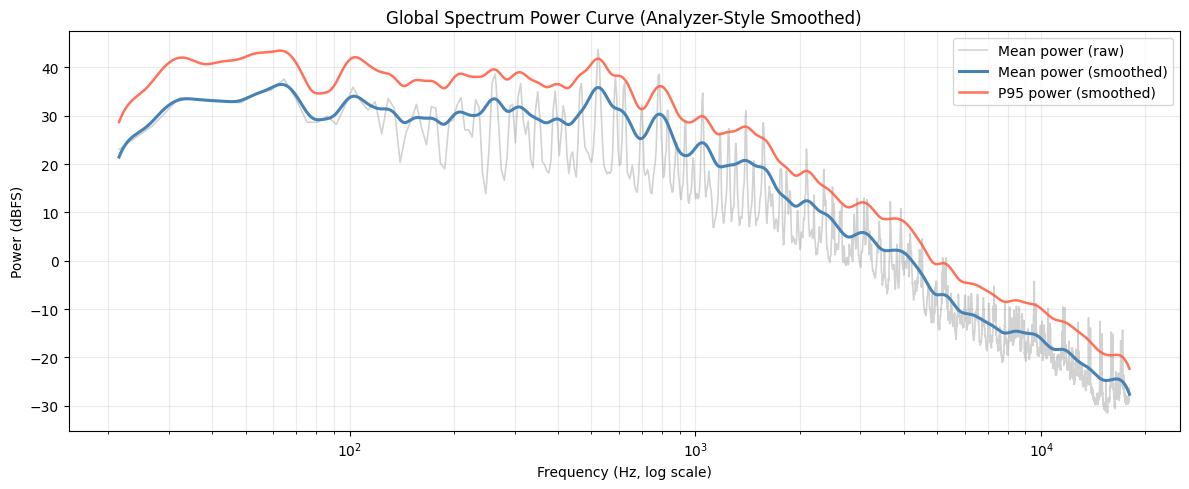

In [10]:
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np

# Reusable global spectrum-style power curve utilities.

EPS = 1e-12


def _resolve_first_existing_path(candidates):
    candidate_paths = [Path(c) for c in candidates]
    if "first_existing_path" in globals():
        return Path(first_existing_path(candidate_paths))

    for candidate in candidate_paths:
        resolved = candidate.expanduser().resolve()
        if resolved.exists():
            return resolved

    tried = [str(c.expanduser().resolve()) for c in candidate_paths]
    raise FileNotFoundError(f"Could not find any candidate path. Tried: {tried}")


def compute_global_spectrum_power_curve(
    track_path,
    sample_rate=44100,
    n_fft=8192,
    hop_length=2048,
    min_hz=20.0,
    max_hz=18000.0,
    smooth_octaves=(1.0 / 6.0),
    log_grid_points=2048,
):
    track_path = Path(track_path).expanduser().resolve()
    if not track_path.exists():
        raise FileNotFoundError(f"Track not found: {track_path}")

    audio, sr = librosa.load(str(track_path), sr=sample_rate, mono=True)
    audio = np.asarray(audio, dtype=np.float32)

    stft = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length, center=True)
    power_spec = np.square(np.abs(stft).astype(np.float64))
    freqs_hz = librosa.fft_frequencies(sr=sr, n_fft=n_fft).astype(np.float64)

    mask = (freqs_hz >= float(min_hz)) & (freqs_hz <= float(max_hz)) & np.isfinite(freqs_hz)
    if np.count_nonzero(mask) < 8:
        raise RuntimeError("Not enough frequency bins in selected range for spectrum curve.")

    freq_sel = freqs_hz[mask]
    mean_power = np.mean(power_spec[mask, :], axis=1) + EPS
    mean_dbfs_raw = 10.0 * np.log10(mean_power)

    p95_power = np.percentile(power_spec[mask, :], 95.0, axis=1) + EPS
    p95_dbfs_raw = 10.0 * np.log10(p95_power)

    # Smooth on a uniform log-frequency grid to mimic analyzer curve behavior.
    log_freq = np.log2(freq_sel)
    log_grid = np.linspace(
        float(log_freq.min()),
        float(log_freq.max()),
        int(log_grid_points),
        dtype=np.float64,
    )
    freq_grid_hz = np.power(2.0, log_grid)

    mean_power_grid = np.interp(log_grid, log_freq, mean_power)
    p95_power_grid = np.interp(log_grid, log_freq, p95_power)

    step_oct = float(log_grid[1] - log_grid[0])
    if step_oct <= 0:
        raise RuntimeError("Invalid log-frequency grid step.")

    sigma_oct = float(smooth_octaves) / np.sqrt(8.0 * np.log(2.0))
    sigma_bins = max(1e-6, sigma_oct / step_oct)
    radius = int(np.ceil(4.0 * sigma_bins))
    kx = np.arange(-radius, radius + 1, dtype=np.float64)
    kernel = np.exp(-0.5 * np.square(kx / sigma_bins))
    kernel /= np.sum(kernel)

    mean_power_smooth = np.convolve(mean_power_grid, kernel, mode="same")
    p95_power_smooth = np.convolve(p95_power_grid, kernel, mode="same")

    mean_dbfs_smooth = 10.0 * np.log10(mean_power_smooth + EPS)
    p95_dbfs_smooth = 10.0 * np.log10(p95_power_smooth + EPS)

    return {
        "track_path": str(track_path),
        "sample_rate": int(sr),
        "n_fft": int(n_fft),
        "hop_length": int(hop_length),
        "min_hz": float(min_hz),
        "max_hz": float(max_hz),
        "smooth_octaves": float(smooth_octaves),
        "log_grid_points": int(log_grid_points),
        "freq_raw_hz": freq_sel.astype(np.float32),
        "mean_dbfs_raw": mean_dbfs_raw.astype(np.float32),
        "p95_dbfs_raw": p95_dbfs_raw.astype(np.float32),
        "freq_hz": freq_grid_hz.astype(np.float32),
        "mean_dbfs": mean_dbfs_smooth.astype(np.float32),
        "p95_dbfs": p95_dbfs_smooth.astype(np.float32),
    }


def plot_global_spectrum_power_curve(curve, title=None, include_raw=True, ax=None):
    created_fig = False
    if ax is None:
        created_fig = True
        fig, ax = plt.subplots(figsize=(12, 5))
    else:
        fig = ax.figure

    if include_raw:
        ax.semilogx(
            curve["freq_raw_hz"],
            curve["mean_dbfs_raw"],
            color="gray",
            alpha=0.35,
            linewidth=1.2,
            label="Mean power (raw)",
        )

    ax.semilogx(
        curve["freq_hz"],
        curve["mean_dbfs"],
        color="steelblue",
        linewidth=2.2,
        label="Mean power (smoothed)",
    )
    ax.semilogx(
        curve["freq_hz"],
        curve["p95_dbfs"],
        color="tomato",
        linewidth=1.8,
        alpha=0.9,
        label="P95 power (smoothed)",
    )

    if title is None:
        title = "Global Spectrum Power Curve (Analyzer-Style Smoothed)"
    ax.set_title(title)
    ax.set_xlabel("Frequency (Hz, log scale)")
    ax.set_ylabel("Power (dBFS)")
    ax.grid(alpha=0.25, which="both")
    ax.legend(loc="best")

    if created_fig:
        fig.tight_layout()
        plt.show()


# Single-track example (uses the MP3 defined here).
SPECTRUM_TRACK_CANDIDATES = [
    Path("../music/aries-mix/filmic.mp3"),
    Path("music/aries-mix/filmic.mp3"),
]
SPECTRUM_SAMPLE_RATE = 44100
SPECTRUM_N_FFT = 8192
SPECTRUM_HOP_LENGTH = 2048
SPECTRUM_MIN_HZ = 20.0
SPECTRUM_MAX_HZ = 18000.0
SPECTRUM_SMOOTH_OCTAVES = 1.0 / 6.0
SPECTRUM_LOG_GRID_POINTS = 2048

spectrum_track_path = _resolve_first_existing_path(SPECTRUM_TRACK_CANDIDATES)
global_spectrum_curve = compute_global_spectrum_power_curve(
    track_path=spectrum_track_path,
    sample_rate=SPECTRUM_SAMPLE_RATE,
    n_fft=SPECTRUM_N_FFT,
    hop_length=SPECTRUM_HOP_LENGTH,
    min_hz=SPECTRUM_MIN_HZ,
    max_hz=SPECTRUM_MAX_HZ,
    smooth_octaves=SPECTRUM_SMOOTH_OCTAVES,
    log_grid_points=SPECTRUM_LOG_GRID_POINTS,
)

# Backward-compatible outputs used by downstream cells.
global_spectrum_freq_hz = global_spectrum_curve["freq_hz"]
global_spectrum_mean_dbfs = global_spectrum_curve["mean_dbfs"]
global_spectrum_p95_dbfs = global_spectrum_curve["p95_dbfs"]

print(f"Spectrum track: {global_spectrum_curve['track_path']}")
print(
    f"SR={global_spectrum_curve['sample_rate']} | N_FFT={global_spectrum_curve['n_fft']} | "
    f"Hop={global_spectrum_curve['hop_length']} | "
    f"Freq range={global_spectrum_curve['min_hz']:.0f}-{global_spectrum_curve['max_hz']:.0f} Hz"
)
print(
    f"Smoothing: {global_spectrum_curve['smooth_octaves']:.3f} oct FWHM on log-frequency grid "
    f"({global_spectrum_curve['log_grid_points']} points)"
)

plot_global_spectrum_power_curve(global_spectrum_curve)



/var/folders/gw/gyqm76mn3d3_vjqrr211cp3m0000gn/T/ipykernel_68288/685667635.py:283: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


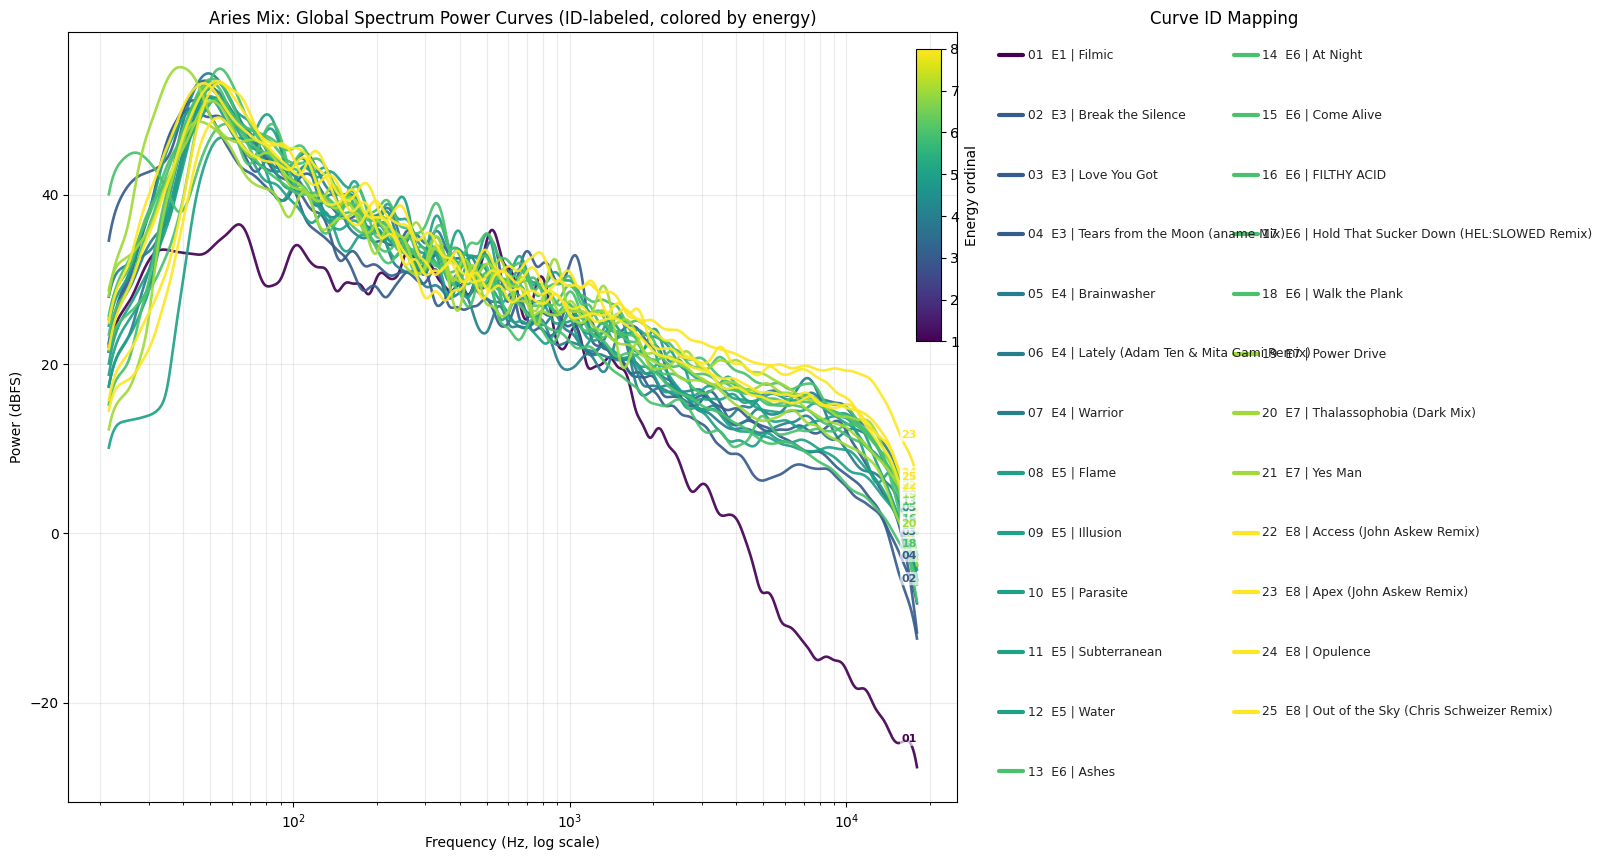

Processed 25 tracks from /Users/josephdaher/Git Repositories/djprojectexploration/music/aries-mix/aries_mix_tracks.csv


In [11]:
from pathlib import Path
import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Batch spectrum power curves for all Aries mix tracks.
# Color uses ordinal "energy" tag from aries_mix_tracks.csv.
# To avoid legend overlap, this plot uses:
# 1) numeric IDs directly on curve endpoints
# 2) a separate track-mapping panel with ID -> song mapping

# Make this cell resilient if the previous single-track cell was not run.
SPECTRUM_SAMPLE_RATE = int(globals().get("SPECTRUM_SAMPLE_RATE", 44100))
SPECTRUM_N_FFT = int(globals().get("SPECTRUM_N_FFT", 8192))
SPECTRUM_HOP_LENGTH = int(globals().get("SPECTRUM_HOP_LENGTH", 2048))
SPECTRUM_MIN_HZ = float(globals().get("SPECTRUM_MIN_HZ", 20.0))
SPECTRUM_MAX_HZ = float(globals().get("SPECTRUM_MAX_HZ", 18000.0))
SPECTRUM_SMOOTH_OCTAVES = float(globals().get("SPECTRUM_SMOOTH_OCTAVES", 1.0 / 6.0))
SPECTRUM_LOG_GRID_POINTS = int(globals().get("SPECTRUM_LOG_GRID_POINTS", 2048))
EPS = 1e-12

if "compute_global_spectrum_power_curve" not in globals():
    try:
        import librosa
    except Exception as exc:
        raise RuntimeError(
            "`compute_global_spectrum_power_curve` is not defined and librosa could not be imported. "
            "Run the `global-spectrum-power-curve` cell first (or install librosa)."
        ) from exc

    def compute_global_spectrum_power_curve(
        track_path,
        sample_rate=44100,
        n_fft=8192,
        hop_length=2048,
        min_hz=20.0,
        max_hz=18000.0,
        smooth_octaves=(1.0 / 6.0),
        log_grid_points=2048,
    ):
        track_path = Path(track_path).expanduser().resolve()
        if not track_path.exists():
            raise FileNotFoundError(f"Track not found: {track_path}")

        audio, sr = librosa.load(str(track_path), sr=sample_rate, mono=True)
        audio = np.asarray(audio, dtype=np.float32)

        stft = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length, center=True)
        power_spec = np.square(np.abs(stft).astype(np.float64))
        freqs_hz = librosa.fft_frequencies(sr=sr, n_fft=n_fft).astype(np.float64)

        mask = (freqs_hz >= float(min_hz)) & (freqs_hz <= float(max_hz)) & np.isfinite(freqs_hz)
        if np.count_nonzero(mask) < 8:
            raise RuntimeError("Not enough frequency bins in selected range for spectrum curve.")

        freq_sel = freqs_hz[mask]
        mean_power = np.mean(power_spec[mask, :], axis=1) + EPS
        p95_power = np.percentile(power_spec[mask, :], 95.0, axis=1) + EPS

        log_freq = np.log2(freq_sel)
        log_grid = np.linspace(
            float(log_freq.min()),
            float(log_freq.max()),
            int(log_grid_points),
            dtype=np.float64,
        )
        freq_grid_hz = np.power(2.0, log_grid)

        mean_power_grid = np.interp(log_grid, log_freq, mean_power)
        p95_power_grid = np.interp(log_grid, log_freq, p95_power)

        step_oct = float(log_grid[1] - log_grid[0])
        if step_oct <= 0:
            raise RuntimeError("Invalid log-frequency grid step.")

        sigma_oct = float(smooth_octaves) / np.sqrt(8.0 * np.log(2.0))
        sigma_bins = max(1e-6, sigma_oct / step_oct)
        radius = int(np.ceil(4.0 * sigma_bins))
        kx = np.arange(-radius, radius + 1, dtype=np.float64)
        kernel = np.exp(-0.5 * np.square(kx / sigma_bins))
        kernel /= np.sum(kernel)

        mean_power_smooth = np.convolve(mean_power_grid, kernel, mode="same")
        p95_power_smooth = np.convolve(p95_power_grid, kernel, mode="same")

        mean_dbfs_smooth = 10.0 * np.log10(mean_power_smooth + EPS)
        p95_dbfs_smooth = 10.0 * np.log10(p95_power_smooth + EPS)

        return {
            "track_path": str(track_path),
            "sample_rate": int(sr),
            "n_fft": int(n_fft),
            "hop_length": int(hop_length),
            "min_hz": float(min_hz),
            "max_hz": float(max_hz),
            "smooth_octaves": float(smooth_octaves),
            "log_grid_points": int(log_grid_points),
            "freq_hz": freq_grid_hz.astype(np.float32),
            "mean_dbfs": mean_dbfs_smooth.astype(np.float32),
            "p95_dbfs": p95_dbfs_smooth.astype(np.float32),
        }

ARIES_METADATA_CANDIDATES = [
    Path("../music/aries-mix/aries_mix_tracks.csv"),
    Path("music/aries-mix/aries_mix_tracks.csv"),
]
ARIES_AUDIO_DIR_CANDIDATES = [
    Path("../music/aries-mix"),
    Path("music/aries-mix"),
]

if "_resolve_first_existing_path" in globals():
    aries_metadata_path = _resolve_first_existing_path(ARIES_METADATA_CANDIDATES)
else:
    aries_metadata_path = None
    for _c in ARIES_METADATA_CANDIDATES:
        _r = _c.expanduser().resolve()
        if _r.exists():
            aries_metadata_path = _r
            break
    if aries_metadata_path is None:
        _tried = [str(c.expanduser().resolve()) for c in ARIES_METADATA_CANDIDATES]
        raise FileNotFoundError(f"Could not find Aries metadata CSV. Tried: {_tried}")

aries_audio_dir = None
for _d in ARIES_AUDIO_DIR_CANDIDATES:
    _rd = _d.expanduser().resolve()
    if _rd.exists() and _rd.is_dir():
        aries_audio_dir = _rd
        break
if aries_audio_dir is None:
    _tried = [str(d.expanduser().resolve()) for d in ARIES_AUDIO_DIR_CANDIDATES]
    raise FileNotFoundError(f"Could not find Aries audio directory. Tried: {_tried}")

with open(aries_metadata_path, newline="", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))

required_cols = {"title", "mp3_name", "energy"}
if not rows:
    raise RuntimeError("Aries metadata CSV is empty.")
missing_cols = sorted(required_cols - set(rows[0].keys()))
if missing_cols:
    raise ValueError(f"Missing required columns in Aries metadata: {missing_cols}")

aries_curves = []
failed_tracks = []

for row in rows:
    title = str(row["title"])
    mp3_name = str(row["mp3_name"])
    try:
        energy_value = float(row["energy"])
    except Exception:
        failed_tracks.append((title, mp3_name, f"invalid_energy={row['energy']!r}"))
        continue

    track_path = (aries_audio_dir / mp3_name).resolve()

    if not track_path.exists():
        failed_tracks.append((title, mp3_name, "missing_file"))
        continue

    try:
        curve = compute_global_spectrum_power_curve(
            track_path=track_path,
            sample_rate=SPECTRUM_SAMPLE_RATE,
            n_fft=SPECTRUM_N_FFT,
            hop_length=SPECTRUM_HOP_LENGTH,
            min_hz=SPECTRUM_MIN_HZ,
            max_hz=SPECTRUM_MAX_HZ,
            smooth_octaves=SPECTRUM_SMOOTH_OCTAVES,
            log_grid_points=SPECTRUM_LOG_GRID_POINTS,
        )
        curve["title"] = title
        curve["mp3_name"] = mp3_name
        curve["energy"] = energy_value
        aries_curves.append(curve)
    except Exception as exc:
        failed_tracks.append((title, mp3_name, str(exc)))

if not aries_curves:
    print(f"Processed 0/{len(rows)} tracks from {aries_metadata_path}")
    print("First failures:")
    for title, mp3_name, reason in failed_tracks[:8]:
        print(f"  - {title} ({mp3_name}): {reason}")
    raise RuntimeError(
        "No Aries tracks were processed successfully. "
        "See failure reasons printed above."
    )

# Stable ordering for IDs (low energy -> high energy, then alphabetical title).
aries_curves = sorted(aries_curves, key=lambda c: (c["energy"], c["title"]))
for idx, curve in enumerate(aries_curves, start=1):
    curve["curve_id"] = idx

energies = np.array([c["energy"] for c in aries_curves], dtype=np.float64)
energy_min = float(np.nanmin(energies))
energy_max = float(np.nanmax(energies))
if energy_max <= energy_min:
    energy_norm = mpl.colors.Normalize(vmin=energy_min - 1.0, vmax=energy_max + 1.0)
else:
    energy_norm = mpl.colors.Normalize(vmin=energy_min, vmax=energy_max)

cmap = plt.cm.viridis

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(1, 2, width_ratios=[3.9, 2.1], wspace=0.04)
ax = fig.add_subplot(gs[0, 0])
ax_map = fig.add_subplot(gs[0, 1])

# Main curves with on-curve numeric IDs.
for curve in aries_curves:
    color = cmap(energy_norm(curve["energy"]))
    x = curve["freq_hz"]
    y = curve["mean_dbfs"]

    ax.semilogx(x, y, color=color, linewidth=1.9, alpha=0.92)

    # Place ID near the high-frequency end to identify each curve directly.
    endpoint_idx = max(0, len(x) - 40)
    x_end = float(x[endpoint_idx])
    y_end = float(y[endpoint_idx])
    cid = int(curve["curve_id"])
    ax.text(
        x_end,
        y_end,
        f"{cid:02d}",
        color=color,
        fontsize=8,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.65),
    )

ax.set_title("Aries Mix: Global Spectrum Power Curves (ID-labeled, colored by energy)")
ax.set_xlabel("Frequency (Hz, log scale)")
ax.set_ylabel("Power (dBFS)")
ax.grid(alpha=0.25, which="both")

# Compact inset colorbar so it doesn't collide with labels.
sm = mpl.cm.ScalarMappable(norm=energy_norm, cmap=cmap)
sm.set_array([])
cax = inset_axes(ax, width="2.8%", height="38%", loc="upper right", borderpad=1.2)
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Energy ordinal")

# Right-side ID -> song mapping panel.
ax_map.set_title("Curve ID Mapping", fontsize=12)
ax_map.set_axis_off()

n_items = len(aries_curves)
n_cols = 2
n_rows = int(np.ceil(n_items / n_cols))
usable_h = 0.93
row_step = usable_h / max(1, n_rows - 1)
col_x = [0.03, 0.52]

for j, curve in enumerate(aries_curves):
    col = j // n_rows
    row = j % n_rows
    x0 = col_x[col]
    y0 = 0.97 - row * row_step

    color = cmap(energy_norm(curve["energy"]))
    cid = int(curve["curve_id"])
    energy_i = int(round(curve["energy"]))
    label = f"{cid:02d}  E{energy_i} | {curve['title']}"

    ax_map.plot([x0, x0 + 0.05], [y0, y0], transform=ax_map.transAxes, color=color, linewidth=3, solid_capstyle="round")
    ax_map.text(
        x0 + 0.06,
        y0,
        label,
        transform=ax_map.transAxes,
        va="center",
        ha="left",
        fontsize=8.8,
        color="#222222",
    )

fig.tight_layout()
plt.show()

print(f"Processed {len(aries_curves)} tracks from {aries_metadata_path}")
if failed_tracks:
    print(f"Skipped {len(failed_tracks)} tracks:")
    for title, mp3_name, reason in failed_tracks:
        print(f"  - {title} ({mp3_name}): {reason}")



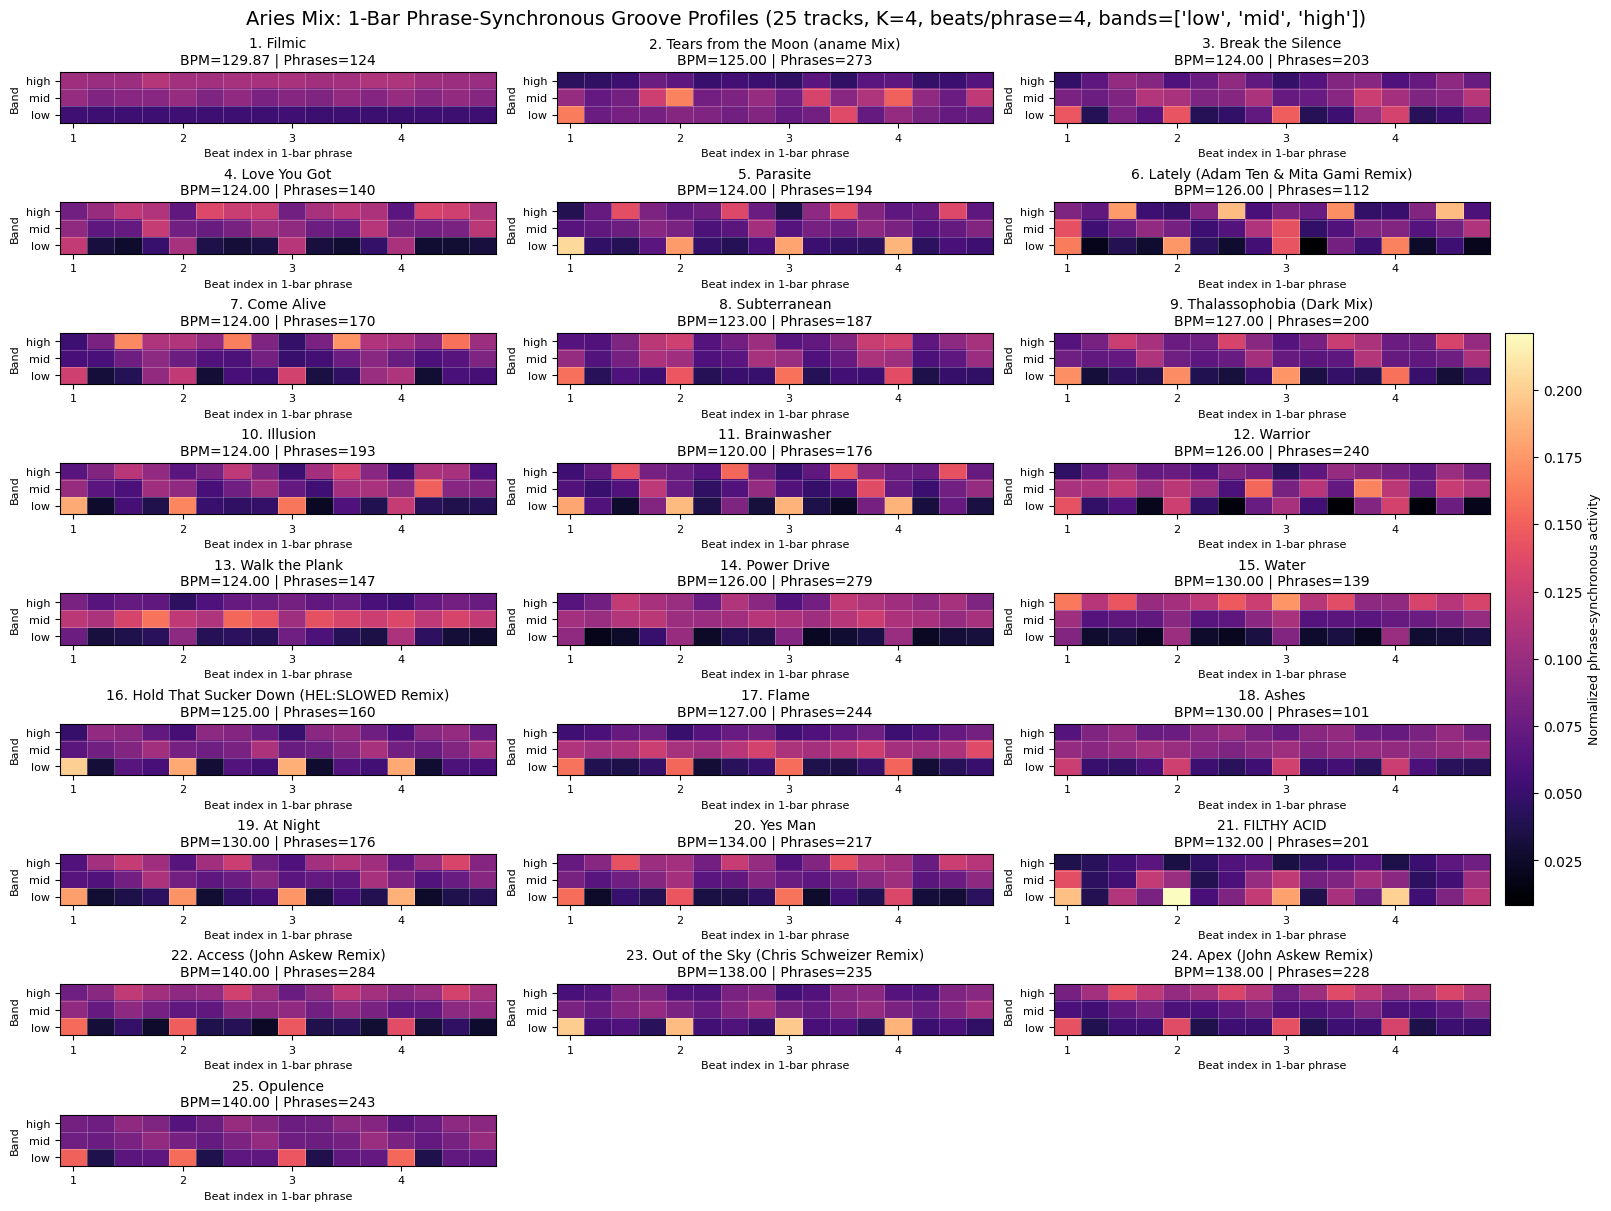

Computed groove profiles for 25 tracks from /Users/josephdaher/Git Repositories/djprojectexploration/music/aries-mix/aries_mix_tracks.csv


In [12]:
# Beat-synchronous groove profile diagram for 9 songs from aries_mix_tracks.csv
# Reuses existing helper functions from this notebook (tempo/beatgrid/onset/groove pipeline).
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt
import librosa
import essentia.standard as es
ARIES_METADATA_CANDIDATES = [
    Path('music/aries-mix/aries_mix_tracks.csv'),
    Path('../music/aries-mix/aries_mix_tracks.csv'),
]
ARIES_MAX_TRACKS = 25
ARIES_PHRASE_BARS = 1
def _resolve_aries_metadata_path(candidates: list[Path]) -> Path:
    if 'first_existing_path' in globals():
        return first_existing_path(candidates)
    for candidate in candidates:
        resolved = candidate.expanduser().resolve()
        if resolved.exists():
            return resolved
    tried = [str(c.expanduser().resolve()) for c in candidates]
    raise FileNotFoundError(f'Could not find Aries metadata CSV. Tried: {tried}')
def _read_aries_rows(metadata_path: Path, max_tracks: int = 9) -> list[dict]:
    rows: list[dict] = []
    with metadata_path.open('r', newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append(row)
            if len(rows) >= int(max_tracks):
                break
    return rows
def _resolve_track_audio_path(metadata_path: Path, mp3_name: str) -> Path:
    base_dir = metadata_path.parent.resolve()
    candidates = [
        (base_dir / mp3_name),
        Path('music/aries-mix') / mp3_name,
        Path('../music/aries-mix') / mp3_name,
    ]
    for c in candidates:
        r = c.expanduser().resolve()
        if r.exists():
            return r
    tried = [str(c.expanduser().resolve()) for c in candidates]
    raise FileNotFoundError(f'Could not resolve audio for {mp3_name}. Tried: {tried}')
def _safe_float(x, default: float | None = None) -> float | None:
    try:
        if x is None:
            return default
        x2 = str(x).strip()
        if not x2:
            return default
        return float(x2)
    except Exception:
        return default
def _compute_groove_profile_for_track(
    track_path: Path,
    *,
    bpm_hint: float | None,
    onset_hint_sec: float | None,
) -> tuple[np.ndarray, np.ndarray, str, float, int]:
    audio = es.MonoLoader(
        filename=str(track_path),
        sampleRate=SAMPLE_RATE,
        resampleQuality=4,
    )()
    audio = audio[: int(float(SNIPPET_SECONDS) * int(SAMPLE_RATE))]
    duration_sec = len(audio) / float(SAMPLE_RATE)
    onset_env_local = librosa.onset.onset_strength(y=audio, sr=SAMPLE_RATE, hop_length=HOP_LENGTH)
    onset_env_times_local = librosa.times_like(onset_env_local, sr=SAMPLE_RATE, hop_length=HOP_LENGTH)
    # Prefer metadata BPM/onset when available; otherwise fallback to TempoCNN path.
    if bpm_hint is not None and np.isfinite(bpm_hint) and bpm_hint > 0:
        bpm_seed = float(bpm_hint)
        phase_anchor_sec = float(max(0.0, onset_hint_sec if onset_hint_sec is not None else 0.0))
        beat_times_local = build_beat_grid_from_bpm_onset(
            audio_duration=duration_sec,
            bpm=bpm_seed,
            first_onset_sec=phase_anchor_sec,
        )
        beat_source_local = 'metadata_bpm_grid'
    else:
        tempocnn_model_file_local = resolve_tempocnn_model_file(
            TEMPOCNN_MODEL_CANDIDATES,
            auto_download=bool(TEMPOCNN_AUTO_DOWNLOAD_MODEL),
            model_url=TEMPOCNN_MODEL_URL,
        )
        tempo_result_local = extract_tempocnn_tempo(
            track_path,
            snippet_seconds=SNIPPET_SECONDS,
            sample_rate=TEMPOCNN_SAMPLE_RATE,
            model_file=tempocnn_model_file_local,
        )
        bpm_seed = float(tempo_result_local['global_bpm'])
        if not np.isfinite(bpm_seed) or bpm_seed <= 0:
            bpm_seed = 120.0
        phase_anchor_sec = float(max(0.0, onset_hint_sec if onset_hint_sec is not None else 0.0))
        beat_times_local = build_beat_grid_from_bpm_onset(
            audio_duration=duration_sec,
            bpm=bpm_seed,
            first_onset_sec=phase_anchor_sec,
        )
        beat_source_local = 'tempocnn_bpm_grid'
    # Optional global phase alignment (same logic as main extraction).
    if AUTO_PHASE_ALIGN and beat_times_local.size >= 2:
        alignment_candidates: dict[str, tuple[np.ndarray, np.ndarray]] = {
            'full': (
                np.asarray(onset_env_times_local, dtype=np.float32),
                normalize_to_unit_peak(np.asarray(onset_env_local, dtype=np.float32)),
            )
        }
        stft_mag_phase = np.abs(
            librosa.stft(audio.astype(np.float32), n_fft=N_FFT, hop_length=HOP_LENGTH, center=True)
        )
        freqs_hz_phase = librosa.fft_frequencies(sr=SAMPLE_RATE, n_fft=N_FFT)
        frame_times_phase = librosa.frames_to_time(
            np.arange(stft_mag_phase.shape[1]),
            sr=SAMPLE_RATE,
            hop_length=HOP_LENGTH,
        ).astype(np.float32)
        low_band = BANDS_HZ.get('low')
        mid_band = BANDS_HZ.get('mid')
        if low_band is not None and mid_band is not None:
            low_env_phase = band_onset_flux(stft_mag_phase, freqs_hz_phase, *low_band)
            mid_env_phase = band_onset_flux(stft_mag_phase, freqs_hz_phase, *mid_band)
            low_w, mid_w = PHASE_ALIGN_LOW_MID_WEIGHTS
            low_mid_env_phase = normalize_to_unit_peak(
                (float(low_w) * low_env_phase + float(mid_w) * mid_env_phase).astype(np.float32)
            )
            if low_mid_env_phase.size == frame_times_phase.size and np.any(low_mid_env_phase > 0):
                alignment_candidates['low_mid'] = (frame_times_phase, low_mid_env_phase)
        phase_align_scores_local: dict[str, float] = {}
        phase_align_shifts_local: dict[str, float] = {}
        for mode_name, (cand_times, cand_env) in alignment_candidates.items():
            shift, score = estimate_global_onset_phase_shift_score(
                beat_times=beat_times_local,
                onset_times=cand_times,
                onset_env=cand_env,
                max_shift_sec=PHASE_ALIGN_MAX_SHIFT_SEC,
                step_sec=PHASE_ALIGN_STEP_SEC,
            )
            phase_align_shifts_local[mode_name] = float(shift)
            phase_align_scores_local[mode_name] = float(score)
        requested_mode = str(PHASE_ALIGN_ENVELOPE_MODE).strip().lower()
        if requested_mode not in {'full', 'low_mid', 'adaptive'}:
            requested_mode = 'adaptive'
        if requested_mode == 'full':
            phase_mode = 'full'
        elif requested_mode == 'low_mid':
            phase_mode = 'low_mid' if 'low_mid' in phase_align_shifts_local else 'full'
        else:
            if 'full' in phase_align_scores_local and 'low_mid' in phase_align_scores_local:
                if phase_align_scores_local['low_mid'] >= phase_align_scores_local['full'] + float(PHASE_ALIGN_ADAPTIVE_MARGIN):
                    phase_mode = 'low_mid'
                else:
                    phase_mode = 'full'
            elif 'low_mid' in phase_align_scores_local:
                phase_mode = 'low_mid'
            else:
                phase_mode = 'full'
        phase_shift_sec = float(phase_align_shifts_local.get(phase_mode, 0.0))
        shifted = beat_times_local + phase_shift_sec
        shifted = shifted[(shifted >= 0.0) & (shifted <= duration_sec)]
        shifted = np.unique(shifted.astype(np.float32))
        if shifted.size >= 2:
            beat_times_local = shifted
            beat_source_local = f'{beat_source_local}_phase_aligned_{phase_mode}'
    if AUTO_PREPEND_START_BEATS:
        beat_times_local, prepended_count_local = prepend_missing_start_beats(
            beat_times=beat_times_local,
            duration_sec=duration_sec,
            fallback_bpm=bpm_seed,
            max_missing_beats=MAX_MISSING_START_BEATS,
            snap_tolerance_sec=START_BEAT_SNAP_TOL_SEC,
        )
        if prepended_count_local > 0:
            beat_source_local = f'{beat_source_local}_prepended_start_{prepended_count_local}'
    stft_mag_local = np.abs(librosa.stft(audio.astype(np.float32), n_fft=N_FFT, hop_length=HOP_LENGTH, center=True))
    freqs_hz_local = librosa.fft_frequencies(sr=SAMPLE_RATE, n_fft=N_FFT)
    frame_times_local = librosa.frames_to_time(
        np.arange(stft_mag_local.shape[1]),
        sr=SAMPLE_RATE,
        hop_length=HOP_LENGTH,
    )
    band_names_local = list(BANDS_HZ.keys())
    band_envs_local = [
        band_onset_flux(stft_mag_local, freqs_hz_local, *BANDS_HZ[name])
        for name in band_names_local
    ]
    beat_sync_tensor_local = beat_sync_multiband_tensor(
        beat_times=beat_times_local,
        frame_times=frame_times_local,
        band_envs=band_envs_local,
        subdivisions=SUBDIVISIONS_PER_BEAT,
        pooling_mode=POOLING_MODE,
        pooling_topk=POOLING_TOPK,
    )
    phrase_beats_local = max(1, int(BEATS_PER_BAR) * int(ARIES_PHRASE_BARS))
    phrase_subdivisions_local = int(SUBDIVISIONS_PER_BEAT) * phrase_beats_local
    n_complete_phrases_local = 0

    if beat_sync_tensor_local.size == 0:
        groove_profile_local = np.zeros((phrase_subdivisions_local, len(band_names_local)), dtype=np.float32)
    else:
        n_complete_beats = (beat_sync_tensor_local.shape[0] // phrase_beats_local) * phrase_beats_local
        if n_complete_beats >= phrase_beats_local:
            phrase_tensor_local = beat_sync_tensor_local[:n_complete_beats].reshape(
                -1,
                phrase_beats_local,
                int(SUBDIVISIONS_PER_BEAT),
                len(band_names_local),
            )
            phrase_tensor_local = phrase_tensor_local.reshape(
                phrase_tensor_local.shape[0],
                phrase_subdivisions_local,
                len(band_names_local),
            )
            groove_profile_local = phrase_tensor_local.mean(axis=0).astype(np.float32)
            n_complete_phrases_local = int(phrase_tensor_local.shape[0])
        else:
            # If too few beats for a full phrase, tile the mean beat profile to phrase length.
            beat_profile_local = beat_sync_tensor_local.mean(axis=0).astype(np.float32)
            groove_profile_local = np.tile(beat_profile_local, (phrase_beats_local, 1)).astype(np.float32)

    bpm_from_grid_local = bpm_from_beat_times(beat_times_local, fallback_bpm=bpm_seed)
    return (
        groove_profile_local,
        np.asarray(band_names_local, dtype=object),
        beat_source_local,
        float(bpm_from_grid_local),
        int(n_complete_phrases_local),
    )
aries_metadata_path = _resolve_aries_metadata_path(ARIES_METADATA_CANDIDATES)
aries_rows = _read_aries_rows(aries_metadata_path, max_tracks=ARIES_MAX_TRACKS)
if len(aries_rows) == 0:
    raise RuntimeError(f'No rows found in {aries_metadata_path}')
profiles: list[dict] = []
failed: list[tuple[str, str, str]] = []
for row in aries_rows:
    title = str(row.get('title', '')).strip() or '<untitled>'
    mp3_name = str(row.get('mp3_name', '')).strip()
    bpm_hint = _safe_float(row.get('bpm'), default=None)
    onset_hint = _safe_float(row.get('onset-time'), default=0.0)
    try:
        if not mp3_name:
            raise ValueError('missing mp3_name in CSV row')
        track_path = _resolve_track_audio_path(aries_metadata_path, mp3_name)
        profile, profile_band_names, beat_source_used, bpm_used, phrase_count_used = _compute_groove_profile_for_track(
            track_path,
            bpm_hint=bpm_hint,
            onset_hint_sec=onset_hint,
        )
        profiles.append({
            'title': title,
            'track_number': str(row.get('track_number', '')).strip(),
            'path': track_path,
            'profile': profile,
            'beat_source': beat_source_used,
            'bpm': bpm_used,
            'band_names': profile_band_names,
            'n_phrases': int(phrase_count_used),
        })
    except Exception as exc:
        failed.append((title, mp3_name, str(exc)))
if len(profiles) == 0:
    raise RuntimeError('Failed to compute groove profiles for all selected tracks.')
band_names_plot = profiles[0]['band_names'].tolist()
n_bands = len(band_names_plot)
all_values = np.concatenate([p['profile'].reshape(-1) for p in profiles]).astype(np.float32)
vmin = float(np.min(all_values))
vmax = float(np.max(all_values))
if vmax <= vmin:
    vmax = vmin + 1e-6
n = min(len(profiles), ARIES_MAX_TRACKS)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 12), constrained_layout=True)
axes = np.asarray(axes).reshape(-1)
last_im = None
for ax_idx, ax in enumerate(axes):
    if ax_idx >= n:
        ax.axis('off')
        continue
    item = profiles[ax_idx]
    profile = np.asarray(item['profile'], dtype=np.float32)  # (subdivisions, bands)
    grid = profile.T  # (bands, subdivisions)
    im = ax.imshow(
        grid,
        aspect='auto',
        origin='lower',
        interpolation='nearest',
        cmap='magma',
        vmin=vmin,
        vmax=vmax,
    )
    last_im = im
    track_number = item['track_number'] or f'{ax_idx + 1}'
    ax.set_title(
        f"{track_number}. {item['title']}\nBPM={item['bpm']:.2f} | Phrases={item['n_phrases']}",
        fontsize=10,
    )
    beat_tick_step = int(max(1, SUBDIVISIONS_PER_BEAT))
    beat_tick_pos = np.arange(0, profile.shape[0], beat_tick_step, dtype=np.int64)
    if beat_tick_pos.size == 0:
        beat_tick_pos = np.array([0], dtype=np.int64)
    ax.set_xticks(beat_tick_pos)
    ax.set_xticklabels([str(i + 1) for i in range(beat_tick_pos.size)], fontsize=8)
    ax.set_xlabel(f'Beat index in {ARIES_PHRASE_BARS}-bar phrase', fontsize=8)
    ax.set_yticks(np.arange(n_bands, dtype=np.int64))
    ax.set_yticklabels(band_names_plot, fontsize=8)
    ax.set_ylabel('Band', fontsize=8)
    # Light cell boundaries for readability.
    ax.set_xticks(np.arange(-0.5, profile.shape[0], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_bands, 1), minor=True)
    ax.grid(which='minor', color='white', linestyle='-', linewidth=0.5, alpha=0.35)
    ax.tick_params(which='minor', bottom=False, left=False)
if last_im is not None:
    cbar = fig.colorbar(last_im, ax=axes.tolist(), fraction=0.02, pad=0.01)
    cbar.set_label('Normalized phrase-synchronous activity', fontsize=9)
fig.suptitle(
    f'Aries Mix: {ARIES_PHRASE_BARS}-Bar Phrase-Synchronous Groove Profiles '
    f'({n} tracks, K={SUBDIVISIONS_PER_BEAT}, beats/phrase={int(BEATS_PER_BAR) * int(ARIES_PHRASE_BARS)}, bands={band_names_plot})',
    fontsize=14,
)
plt.show()
print(f'Computed groove profiles for {len(profiles)} tracks from {aries_metadata_path}')
if failed:
    print(f'Skipped {len(failed)} tracks:')
    for title, mp3_name, reason in failed:
        print(f'  - {title} ({mp3_name}): {reason}')


Band names: ['low', 'mid', 'high']
Band weights vector: [0.3, 0.4, 0.3]
Similarity matrix shape: (25, 25)
Similarity range for colormap: min=0.7836, max=1.0000


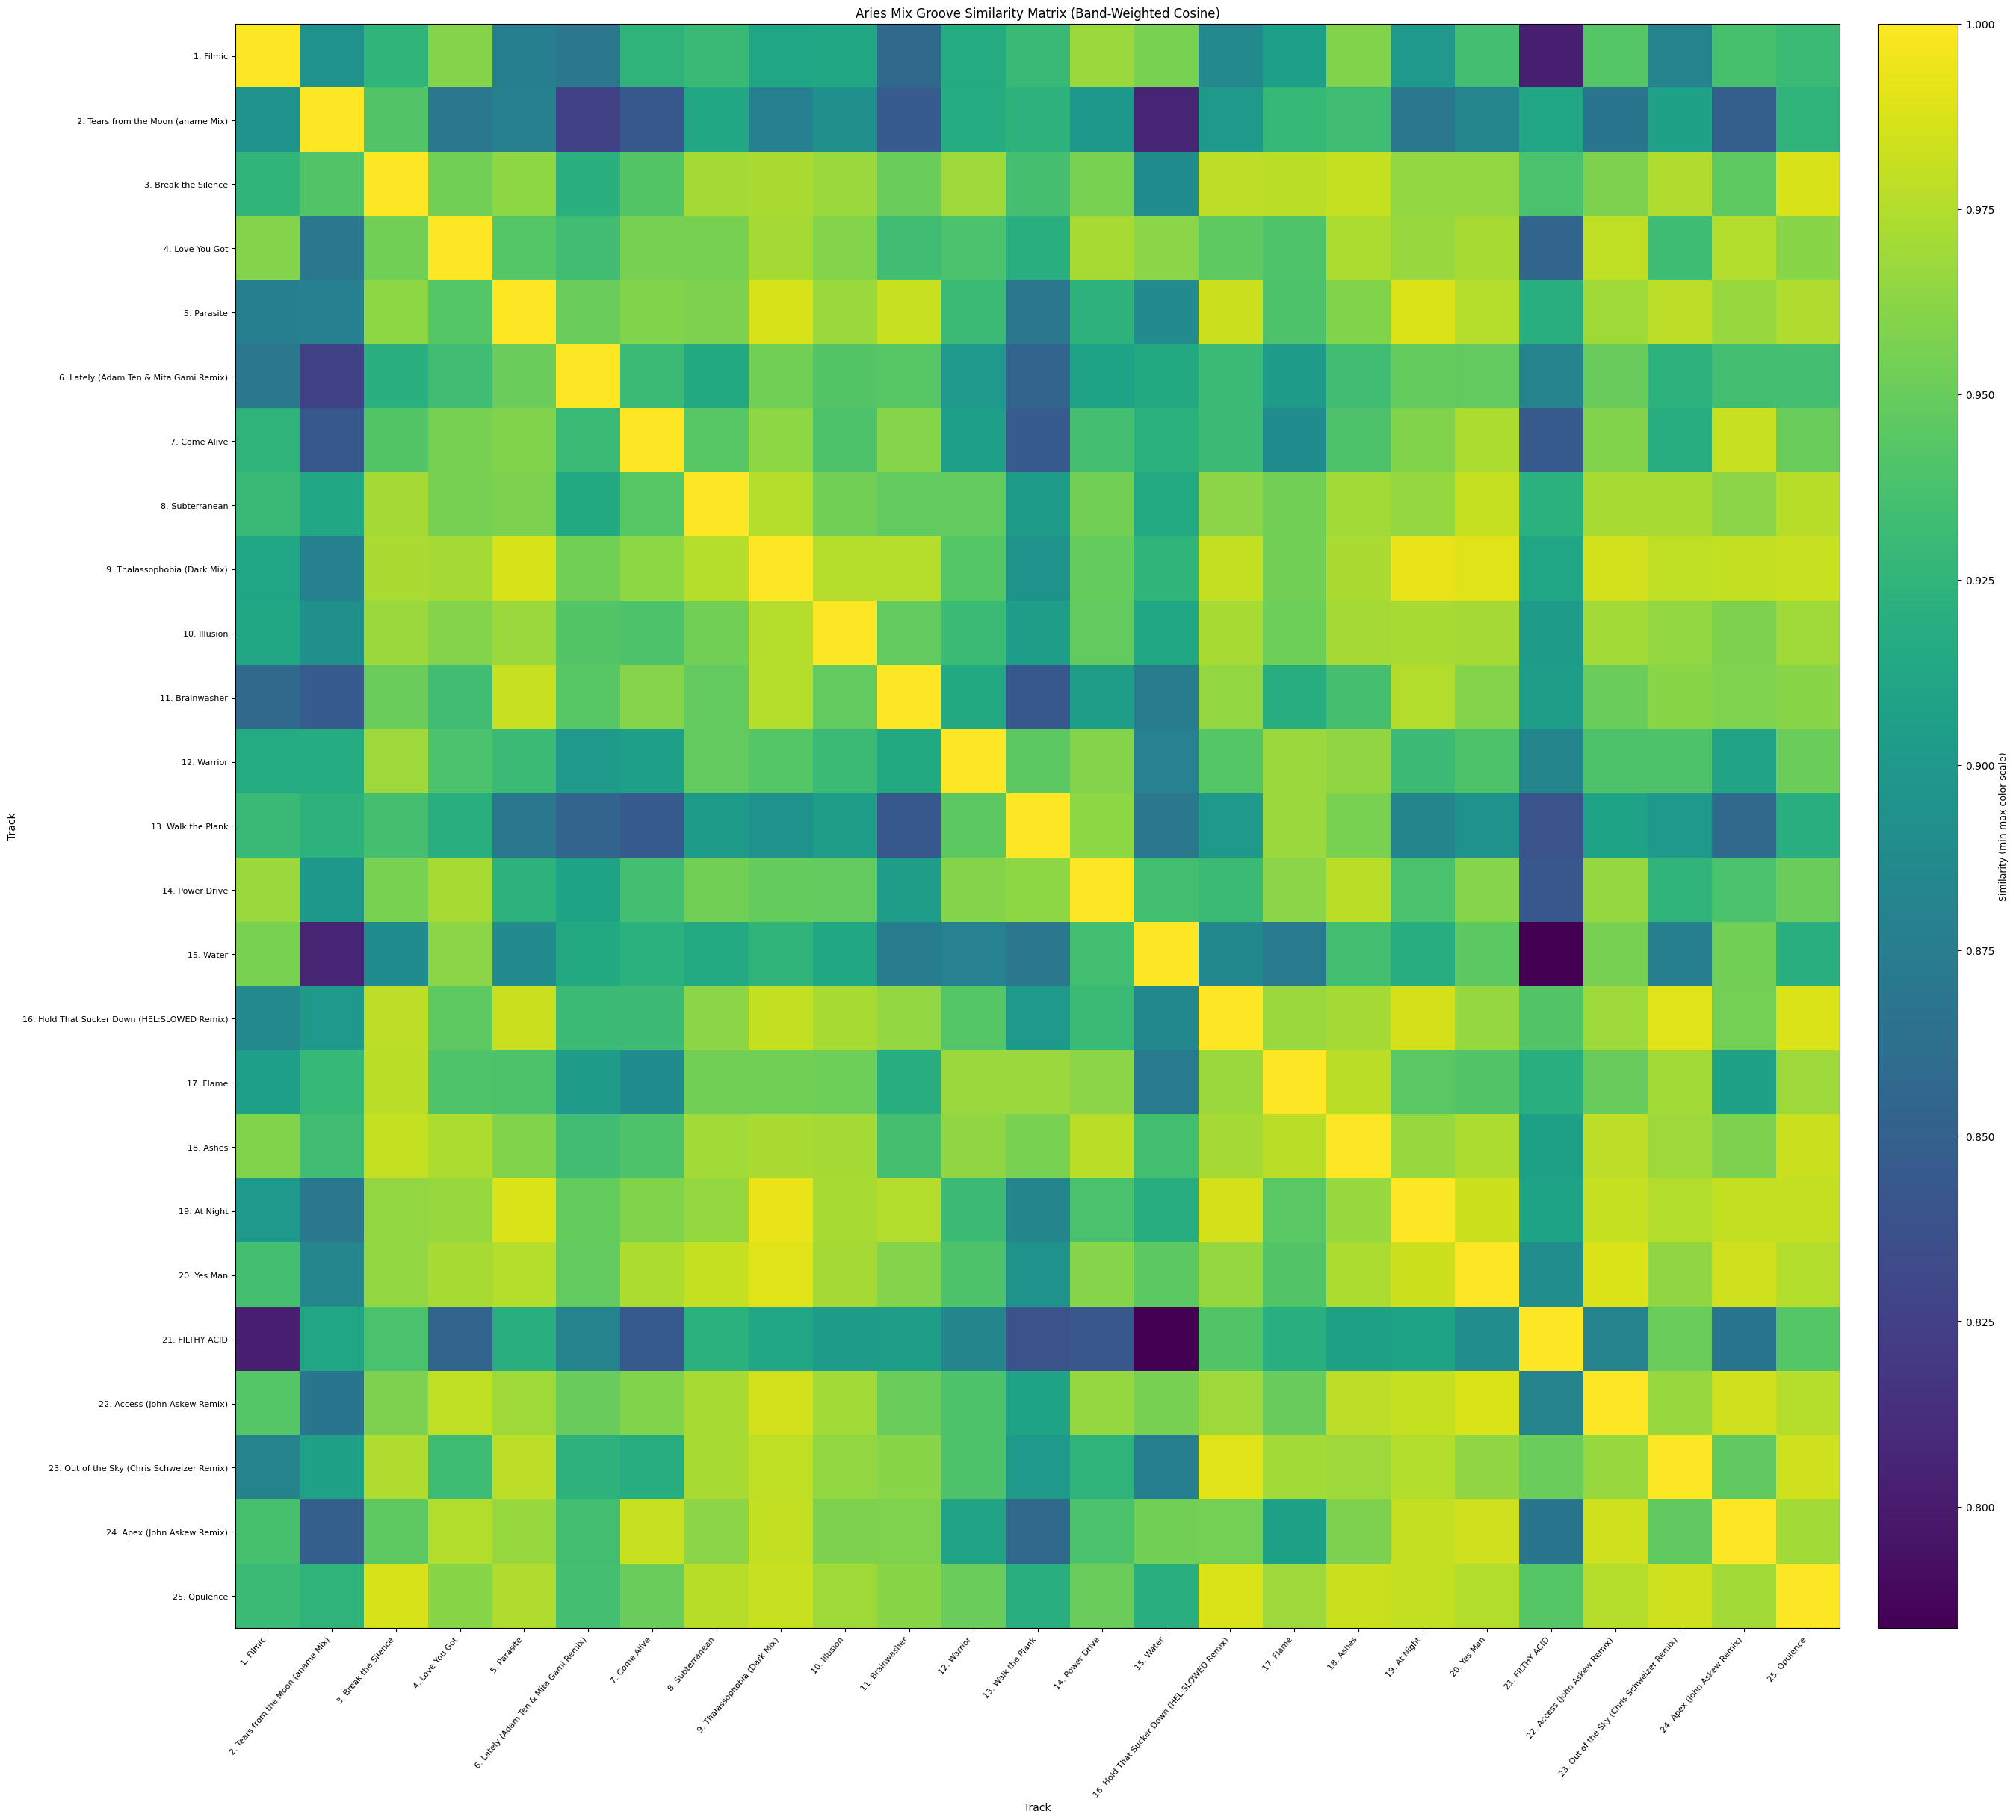

In [13]:
# Pairwise groove similarity (band-weighted cosine) for Aries profiles computed above.

import numpy as np
import matplotlib.pyplot as plt

if 'profiles' not in globals() or len(profiles) == 0:
    raise RuntimeError('No groove profiles found. Run cell `groove-profile-grid-aries9` first.')

# Explicit band-weight parameter (aligned by band name).
# Tune as needed: low > mid > high is common for groove/mixability.
GROOVE_SIM_BAND_WEIGHTS = {
    'low': 0.3,
    'mid': 0.4,
    'high': 0.3,
}

GROOVE_SIM_EPS = 1e-12
GROOVE_SIM_ANNOTATE_VALUES = True


def _resolve_band_weight_vector(
    band_names: list[str],
    band_weights: dict[str, float] | np.ndarray,
) -> np.ndarray:
    if isinstance(band_weights, dict):
        w = np.array([
            float(band_weights.get(str(name), 1.0))
            for name in band_names
        ], dtype=np.float64)
    else:
        w = np.asarray(band_weights, dtype=np.float64).reshape(-1)
        if w.size != len(band_names):
            raise ValueError(
                f'band_weights size ({w.size}) must match band count ({len(band_names)}).'
            )
    if np.any(~np.isfinite(w)):
        raise ValueError('band_weights must be finite.')
    if np.any(w < 0.0):
        raise ValueError('band_weights must be non-negative.')
    if np.sum(w) <= 0.0:
        raise ValueError('band_weights must not all be zero.')
    return w


def weighted_cosine_profile(
    profile_a: np.ndarray,
    profile_b: np.ndarray,
    *,
    band_weights: np.ndarray,
    eps: float = GROOVE_SIM_EPS,
) -> float:
    A = np.asarray(profile_a, dtype=np.float64)
    B = np.asarray(profile_b, dtype=np.float64)
    if A.shape != B.shape:
        raise ValueError(f'Profile shape mismatch: {A.shape} vs {B.shape}')
    if A.ndim != 2:
        raise ValueError(f'Expected 2D profiles, got shape {A.shape}')

    w_band = np.asarray(band_weights, dtype=np.float64).reshape(1, -1)
    if w_band.shape[1] != A.shape[1]:
        raise ValueError(
            f'Band-weight length ({w_band.shape[1]}) does not match profile bands ({A.shape[1]}).'
        )

    weighted_dot = float(np.sum(w_band * A * B))
    weighted_norm_a = float(np.sum(w_band * A * A))
    weighted_norm_b = float(np.sum(w_band * B * B))
    denom = np.sqrt(weighted_norm_a * weighted_norm_b) + float(eps)
    return float(weighted_dot / denom)


def pairwise_weighted_cosine_matrix(
    profile_items: list[dict],
    *,
    band_weights: dict[str, float] | np.ndarray,
    eps: float = GROOVE_SIM_EPS,
) -> tuple[np.ndarray, np.ndarray, list[str]]:
    if len(profile_items) == 0:
        raise ValueError('profile_items is empty.')

    band_names = np.asarray(profile_items[0]['band_names'], dtype=object).astype(str).tolist()
    w_vec = _resolve_band_weight_vector(band_names, band_weights)

    n = len(profile_items)
    S = np.zeros((n, n), dtype=np.float64)
    for i in range(n):
        S[i, i] = 1.0
        for j in range(i + 1, n):
            sim = weighted_cosine_profile(
                np.asarray(profile_items[i]['profile'], dtype=np.float32),
                np.asarray(profile_items[j]['profile'], dtype=np.float32),
                band_weights=w_vec,
                eps=eps,
            )
            S[i, j] = sim
            S[j, i] = sim
    return S, w_vec, band_names


sim_matrix, sim_band_w, sim_band_names = pairwise_weighted_cosine_matrix(
    profiles,
    band_weights=GROOVE_SIM_BAND_WEIGHTS,
    eps=GROOVE_SIM_EPS,
)

n = sim_matrix.shape[0]
labels = []
for i, item in enumerate(profiles, start=1):
    track_no = str(item.get('track_number', '')).strip() or str(i)
    title = str(item.get('title', '<untitled>')).strip()
    labels.append(f"{track_no}. {title}")

fig_w = max(8.0, 0.95 * n + 4.0)
fig_h = max(7.0, 0.85 * n + 3.0)
fig, ax = plt.subplots(figsize=(fig_w, fig_h), constrained_layout=True)

sim_vmin = float(np.min(sim_matrix))
sim_vmax = float(np.max(sim_matrix))
if not np.isfinite(sim_vmin) or not np.isfinite(sim_vmax):
    raise ValueError('Similarity matrix contains non-finite values.')
if sim_vmax <= sim_vmin:
    sim_vmax = sim_vmin + 1e-6
sim_mid = 0.5 * (sim_vmin + sim_vmax)

im = ax.imshow(
    sim_matrix,
    cmap='viridis',
    vmin=sim_vmin,
    vmax=sim_vmax,
    interpolation='nearest',
)
ax.set_title('Aries Mix Groove Similarity Matrix (Band-Weighted Cosine)')
ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(labels, rotation=50, ha='right', fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Track')
ax.set_ylabel('Track')

if GROOVE_SIM_ANNOTATE_VALUES and n <= 14:
    for i in range(n):
        for j in range(n):
            val = sim_matrix[i, j]
            txt_color = 'white' if val < sim_mid else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=txt_color)

cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02)
cbar.set_label('Similarity (min-max color scale)', fontsize=9)

print('Band names:', sim_band_names)
print('Band weights vector:', np.array2string(sim_band_w, precision=4, separator=', '))
print('Similarity matrix shape:', sim_matrix.shape)
print(f'Similarity range for colormap: min={sim_vmin:.4f}, max={sim_vmax:.4f}')

plt.show()
